In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import joblib
import warnings
import re
from datetime import datetime

warnings.filterwarnings('ignore')

# Custom transformers for specific data processing tasks
class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    """Extract features from date columns"""
    def __init__(self, date_columns):
        self.date_columns = date_columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.date_columns:
            if col in X.columns:
                X[col] = pd.to_datetime(X[col], errors='coerce')
                X[f'{col}_month'] = X[col].dt.month
                X[f'{col}_dayofweek'] = X[col].dt.dayofweek
                X[f'{col}_year'] = X[col].dt.year
                # Drop original date column
                X = X.drop(columns=[col])
        return X

class IncomeBandEncoder(BaseEstimator, TransformerMixin):
    """Encode income bands to numerical values"""
    def __init__(self):
        self.income_mapping = {
            '50,000 or Below': 0,
            '50,000 to 100,000': 1,
            '100,000 to 200,000': 2,
            '200,000 to 300,000': 3,
            '300,000 to 500,000': 4,
            '500,000 or Above': 5
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if 'Income_Band_SGD' in X.columns:
            X['Income_Band_SGD'] = X['Income_Band_SGD'].map(self.income_mapping)
        return X

class BooleanConverter(BaseEstimator, TransformerMixin):
    """Convert various boolean representations to proper booleans"""
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        bool_columns = ['Partial_Payment_Indicator', 'Repayment_Irregularity_Flags',
                       'Mobile_Number_Active_Status', 'Email_Activity', 'Do_Not_Call_Registry_Data',
                       'WhatsApp_OTT_usage_Indicator', 'Overdraft_or_Low_Balance_Flag',
                       'Delinquency_on_other_Loans']

        for col in bool_columns:
            if col in X.columns:
                X[col] = X[col].astype(str).str.lower().replace({
                    'true': True, 'false': False, '1': True, '0': False,
                    'yes': True, 'no': False
                }).astype(bool)
        return X

class AddressProcessor(BaseEstimator, TransformerMixin):
    """Extract area and pincode from address column but don't encode them"""
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if 'Address' in X.columns:
            # Extract area and pincode from address (these will be kept as passthrough, not encoded)
            extracted_data = X['Address'].apply(self._extract_area_and_pincode)
            X['Area_From_Address'] = extracted_data.apply(lambda x: x[0])
            X['Pincode_From_Address'] = extracted_data.apply(lambda x: x[1])

        return X

    def _extract_area_and_pincode(self, address):
        """Extract area name and pincode from address"""
        if pd.isna(address):
            return (None, None)

        # Common Singapore areas (from your data generation code)
        singapore_areas = [
            "Raffles Place", "Marina Bay", "Suntec City", "Harbourfront",
            "Serangoon Garden", "Marine Parade", "Bukit Timah", "Orchard",
            "Tanjong Pagar", "Chinatown", "Little India", "Kampong Glam",
            "Bugis", "Dhoby Ghaut", "Somerset", "City Hall",
            "Lavender", "Kallang", "Geylang", "Eunos",
            "Bedok", "Tampines", "Pasir Ris", "Simei",
            "Jurong East", "Jurong West", "Clementi", "Bukit Batok",
            "Bukit Panjang", "Choa Chu Kang", "Woodlands", "Yishun",
            "Sembawang", "Ang Mo Kio", "Bishan", "Toa Payoh",
            "Serangoon", "Hougang", "Punggol", "Sengkang"
        ]

        # Look for area names in the address
        address_lower = address.lower()
        area_found = None

        for area in singapore_areas:
            if area.lower() in address_lower:
                area_found = area
                break

        # Extract pincode (6-digit Singapore pincode)
        pincode_match = re.search(r'(\d{6})', address)
        pincode = pincode_match.group(1) if pincode_match else None

        # If no area found using exact match, try to extract from address structure
        if area_found is None:
            # Try to extract the word before "Singapore" or look for common patterns
            match = re.search(r',\s*([^,]+?),\s*Singapore', address, re.IGNORECASE)
            if match:
                potential_area = match.group(1).strip()
                # Check if this potential area is in our list
                for area in singapore_areas:
                    if area.lower() in potential_area.lower():
                        area_found = area
                        break
                else:
                    area_found = potential_area  # Use as-is if not in list

        return (area_found, pincode)

class EmailValidator(BaseEstimator, TransformerMixin):
    """Validate email addresses and extract domain information"""
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if 'Email_ID' in X.columns:
            # Validate email format
            X['Email_Valid_Format'] = X['Email_ID'].apply(self._validate_email_format)

            # Extract domain
            X['Email_Domain'] = X['Email_ID'].apply(self._extract_domain)

            # Check if domain is legitimate (common email providers)
            X['Email_Domain_Legitimate'] = X['Email_Domain'].apply(self._is_legitimate_domain)

            # Check for disposable email domains
            X['Email_Disposable'] = X['Email_Domain'].apply(self._is_disposable_domain)

        return X

    def _validate_email_format(self, email):
        """Validate basic email format"""
        if pd.isna(email) or not isinstance(email, str):
            return False

        email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
        return bool(re.match(email_pattern, email))

    def _extract_domain(self, email):
        """Extract domain from email address"""
        if pd.isna(email) or not isinstance(email, str) or '@' not in email:
            return None

        return email.split('@')[1].lower()

    def _is_legitimate_domain(self, domain):
        """Check if domain is from a legitimate email provider"""
        if pd.isna(domain):
            return False

        legitimate_domains = [
            'gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'live.com',
            'icloud.com', 'protonmail.com', 'zoho.com', 'aol.com', 'mail.com',
            'gmail.com.sg', 'yahoo.com.sg', 'hotmail.com.sg', 'singnet.com.sg',
            'starhub.net.sg', 'pacific.net.sg'
        ]

        return domain in legitimate_domains

    def _is_disposable_domain(self, domain):
        """Check if domain is from a disposable email service"""
        if pd.isna(domain):
            return False

        disposable_domains = [
            'tempmail.com', '10minutemail.com', 'guerrillamail.com',
            'mailinator.com', 'yopmail.com', 'trashmail.com',
            'disposableemail.com', 'fakeinbox.com', 'temp-mail.org'
        ]

        return domain in disposable_domains

class DataLoader(BaseEstimator, TransformerMixin):
    """Load and initial data processing"""
    def __init__(self, file_path, chunk_size=10000):
        self.file_path = file_path
        self.chunk_size = chunk_size

    def fit(self, X, y=None):
        return self

    def transform(self, X=None):
        """Load data from CSV file"""
        print("Loading data...")

        try:
            # Load data as regular CSV (no compression)
            df = pd.read_csv(self.file_path)
            print(f"Successfully loaded {len(df):,} rows")
            return df
        except Exception as e:
            print(f"Error loading data: {e}")
            # Return empty DataFrame with expected structure
            return pd.DataFrame()

class ColumnDropper(BaseEstimator, TransformerMixin):
    """Drop specified columns from the dataset"""
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Drop columns if they exist
        columns_present = [col for col in self.columns_to_drop if col in X.columns]
        X = X.drop(columns=columns_present)
        return X

class SingaporeLoanDataPipeline:
    def __init__(self, file_path):
        self.file_path = file_path
        self.pipeline = None
        self.processed_data = None
        self.column_names = None
        self._build_pipeline()

    def _get_numeric_columns(self):
        """Define numeric columns for preprocessing"""
        return ['Age', 'Loan_Amount_SGD', 'Outstanding_Balance_SGD', 'Day_Past_Due',
                'Tenure', 'Interest_Rate', 'Current_EMI_SGD', 'Number_of_Past_Payments',
                'Amount_Paid_Each_Month_SGD', 'Missed_Payments_Count',
                'Contact_History_Call_Attempts', 'Contact_History_SMS', 'Contact_History_WhatsApp',
                'Contact_History_EmailLogs', 'No_of_Attempts', 'Average_Handling_Time',
                'Credit_Score', 'Recent_Inquiries', 'Loan_Exposure_Across_Banks',
                'Recent_Score_Change', 'Unemployeement_rate_region', 'Inflation_Rate',
                'Interest_Rate_Trend', 'Economic_Stress_Index', 'Income_Band_SGD',
                'Utility_Spend_SGD', 'Shopping_Spend_SGD', 'Entertainment_Spend_SGD',
                'Health_Spend_SGD', 'Education_Spend_SGD', 'Travel_Spend_SGD',
                'Monthly_Spend_Trend_SGD', 'Seasonal_Spend_Variation', 'Weekend_Spend_Ratio',
                'Festive_Season_Spend_SGD', 'Total_Monthly_Spend_SGD', 'Spend_to_Income_Ratio',
                'UPI_Transaction_Count', 'Debit_Card_Transaction_Count', 'Credit_Card_Transaction_Count',
                'Cash_Withdrawal_Count', 'Recurring_Transaction_Count', 'Recurring_Payment_Ratio',
                'Savings_to_Spend_Ratio', 'Spend_Growth_Rate_YoY', 'High_Value_Transaction_Count',
                'Flight_Risk_Score', 'Financial_Stress_Score', 'AAR_Score', 'Financial_Health_Score',
                'Successful_Contacts_Count', 'Contact_Success_Rate', 'Customer_Best_Agent_Interaction_Count',
                'App_Login_Frequency', 'Online_Banking_Activity', 'Monthly_Income_SGD',
                'No_of_Valid_Numbers', 'No_of_Invalid_Numbers', 'Mobile_Number_Change_Count',
                'Mobile_Number_Change_Count_This_Year', 'Address_Change_Count',
                'Address_Change_Count_This_Year', 'Contact_Data_Change_Frequency']

    def _get_categorical_columns(self):
        """Define categorical columns for preprocessing (Region will be encoded here)"""
        return ['Product_Type', 'Payment_Frequency', 'Settlement_History',
                'Channel_used', 'Response_Outcome',
                'Language_Preference', 'Smartphone_Penetration', 'Preferred_Channel',
                'Call_SMS_Activity_Patterns', 'WhatsApp_OTT_usage_Indicator',
                'Regional_Time_Restrictions', 'Communication_Complaince_Limits',
                'Gender', 'Occupation', 'Employeement_Type', 'Customer_Employment_Status',
                'Finance_Stress_Status', 'Preferred_Payment_Channel', 'Financial_Health_Status',
                'Avg_Balance_Trends', 'AAR_Risk_Level', 'Region', 'Area']

    def _get_agent_columns(self):
        """Define agent columns that should be left as-is"""
        return ['Last_Successful_Agent_ID', 'Best_Contact_Agent_IDs']

    def _get_passthrough_columns(self):
        """Define columns that should be passed through without transformation"""
        return ['Area_From_Address', 'Pincode_From_Address', 'Address', 'Pincode',
                'Customer_id', 'Loan_Account_id', 'Name']

    def _get_date_columns(self):
        """Define date columns for processing"""
        return ['Installment_Due_Date', 'Last_Payment_Date']

    def _get_columns_to_drop(self):
        """Define columns to drop from the dataset"""
        return ['Primary_Phone_Number', 'Secondary_Mobile_Number', 'Landline_Phone_Number']

    def _build_pipeline(self):
        """Build the updated pipeline"""

        # Main preprocessing pipeline
        self.pipeline = Pipeline([
            # Step 1: Load data
            ('data_loader', DataLoader(self.file_path)),

            # Step 2: Drop phone number columns
            ('column_dropper', ColumnDropper(self._get_columns_to_drop())),

            # Step 3: Process address information (extract area and pincode but don't encode)
            ('address_processor', AddressProcessor()),

            # Step 4: Validate email addresses
            ('email_validator', EmailValidator()),

            # Step 5: Convert boolean columns
            ('boolean_converter', BooleanConverter()),

            # Step 6: Encode income bands
            ('income_encoder', IncomeBandEncoder()),

            # Step 7: Extract date features
            ('date_extractor', DateFeatureExtractor(self._get_date_columns())),
        ])

    def fit_transform(self, save_path=None):
        """Run the complete pipeline and return processed data"""
        print("=" * 50)
        print("RUNNING SINGAPORE LOAN DATA PIPELINE")
        print("=" * 50)

        try:
            # Run the pipeline steps manually to maintain DataFrame structure
            df = self.pipeline.named_steps['data_loader'].transform(None)
            original_shape = df.shape

            print("Applying preprocessing steps...")
            for step_name, transformer in list(self.pipeline.named_steps.items())[1:]:
                print(f"Applying {step_name}...")
                df = transformer.fit_transform(df)

            # Remove duplicates
            df = df.drop_duplicates()

            # Apply standard preprocessing to categorical columns only
            # Numeric columns will be handled in feature engineering
            categorical_features = [col for col in self._get_categorical_columns() if col in df.columns]
            agent_features = [col for col in self._get_agent_columns() if col in df.columns]
            passthrough_features = [col for col in self._get_passthrough_columns() if col in df.columns]

            # Handle categorical columns (including Region and Area)
            if categorical_features:
                categorical_imputer = SimpleImputer(strategy='most_frequent')
                onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

                # Impute missing values
                df[categorical_features] = categorical_imputer.fit_transform(df[categorical_features])

                # One-hot encode categorical variables (including Region and Area)
                encoded_array = onehot_encoder.fit_transform(df[categorical_features])
                encoded_columns = onehot_encoder.get_feature_names_out(categorical_features)

                # Create DataFrame for encoded features
                encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns, index=df.index)

                # Drop original categorical columns and add encoded ones
                df = df.drop(columns=categorical_features)
                df = pd.concat([df, encoded_df], axis=1)

            # Agent columns, Area_From_Address, Pincode_From_Address, and other passthrough columns are left as-is
            # They remain in the DataFrame

            self.processed_data = df.reset_index(drop=True)

            # Save if path provided
            if save_path:
                self.save_processed_data(save_path)

            print("Pipeline completed successfully!")
            print(f"Original shape: {original_shape}")
            print(f"Processed shape: {self.processed_data.shape}")

            return self.processed_data

        except Exception as e:
            print(f"Error in pipeline: {e}")
            import traceback
            traceback.print_exc()
            return None

    def save_processed_data(self, path):
        """Save the processed data"""
        if self.processed_data is not None:
            self.processed_data.to_csv(path, index=False)
            print(f"Processed data saved to {path}")

            # Also save the pipeline for future use
            joblib.dump(self.pipeline, 'data_pipeline.pkl')
            print("Pipeline saved as 'data_pipeline.pkl'")

    def load_and_transform_new_data(self, new_data_path):
        """Load and transform new data using the fitted pipeline"""
        if self.pipeline is None:
            raise ValueError("Pipeline not fitted yet. Call fit_transform first.")

        # Load new data
        new_data_loader = DataLoader(new_data_path)
        new_df = new_data_loader.transform(None)

        # Apply the same transformations
        for step_name, transformer in list(self.pipeline.named_steps.items())[1:]:
            new_df = transformer.transform(new_df)

        return new_df

# Example usage
if __name__ == "__main__":
    # Initialize the Singapore loan data pipeline
    pipeline = SingaporeLoanDataPipeline('/content/drive/MyDrive/Prototype/singapore_loan_data.csv')

    # Run the complete pipeline
    processed_data = pipeline.fit_transform(save_path='processed_loan_data.csv')

    if processed_data is not None:
        # Display results
        print("\nPipeline Summary:")
        print(f"Processed data shape: {processed_data.shape}")
        print(f"Processed data columns: {len(processed_data.columns)}")

        print("\nSample of processed data:")
        print(processed_data.head())

        print("\nData types after processing:")
        print(processed_data.dtypes.value_counts())
    else:
        print("Pipeline failed to process data.")

RUNNING SINGAPORE LOAN DATA PIPELINE
Loading data...
Successfully loaded 100,000 rows
Applying preprocessing steps...
Applying column_dropper...
Applying address_processor...
Applying email_validator...
Applying boolean_converter...
Applying income_encoder...
Applying date_extractor...
Processed data saved to processed_loan_data.csv
Pipeline saved as 'data_pipeline.pkl'
Pipeline completed successfully!
Original shape: (100000, 111)
Processed shape: (100000, 200)

Pipeline Summary:
Processed data shape: (100000, 200)
Processed data columns: 200

Sample of processed data:
    Customer_id  Loan_Account_id  Loan_Amount_SGD  Outstanding_Balance_SGD  \
0  SCB995374436         57074699          23000.0                 23000.00   
1  SCB912200571         12654741          25000.0                  3425.70   
2  SCB984325727         86582307         460000.0                426977.75   
3  SCB808527216         81512674         115000.0                111939.14   
4  SCB814787866         48765216 

In [2]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
import joblib

warnings.filterwarnings('ignore')

class AARRiskLevelCalculator(BaseEstimator, TransformerMixin):
    """Calculate Customer Risk Level based on AAR Score thresholds"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Include AAR_Score directly if it exists
        if 'AAR_Score' in X.columns:
            # Create Customer Risk Level based on AAR Score thresholds
            conditions = [
                X['AAR_Score'] <= 0.5,
                (X['AAR_Score'] > 0.5) & (X['AAR_Score'] <= 0.65),
                X['AAR_Score'] > 0.65
            ]
            choices = ['Low', 'Medium', 'High']

            X['Customer_Risk_Level'] = np.select(conditions, choices, default='Medium')

        return X

class SpendFeatureEngineer(BaseEstimator, TransformerMixin):
    """Engineer comprehensive features based on spending patterns and behaviors"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # List of available spend categories
        spend_categories = ['Utility_Spend_SGD', 'Shopping_Spend_SGD', 'Entertainment_Spend_SGD',
                           'Health_Spend_SGD', 'Education_Spend_SGD', 'Travel_Spend_SGD']

        available_spend_categories = [col for col in spend_categories if col in X.columns]

        if available_spend_categories and 'Total_Monthly_Spend_SGD' in X.columns:
            # 1. Calculate spend percentages for each category
            for category in available_spend_categories:
                X[f'{category}_Percentage'] = X[category] / X['Total_Monthly_Spend_SGD'].replace(0, 1)

            # 2. Essential vs Non-Essential Spend Ratio
            essential_categories = ['Utility_Spend_SGD', 'Health_Spend_SGD', 'Education_Spend_SGD']
            non_essential_categories = ['Shopping_Spend_SGD', 'Entertainment_Spend_SGD', 'Travel_Spend_SGD']

            available_essential = [cat for cat in essential_categories if cat in available_spend_categories]
            available_non_essential = [cat for cat in non_essential_categories if cat in available_spend_categories]

            if available_essential:
                X['Essential_Spend_Total'] = X[available_essential].sum(axis=1)
                X['Essential_Spend_Ratio'] = X['Essential_Spend_Total'] / X['Total_Monthly_Spend_SGD'].replace(0, 1)

            if available_non_essential:
                X['Non_Essential_Spend_Total'] = X[available_non_essential].sum(axis=1)
                X['Non_Essential_Spend_Ratio'] = X['Non_Essential_Spend_Total'] / X['Total_Monthly_Spend_SGD'].replace(0, 1)

            # 3. Spend Diversity Index (Herfindahl index for spend concentration)
            spend_percentages = [f'{cat}_Percentage' for cat in available_spend_categories]
            if spend_percentages:
                X['Spend_Diversity_Index'] = 1 - (X[spend_percentages] ** 2).sum(axis=1)

            # 4. Luxury vs Necessity Indicator
            if 'Shopping_Spend_SGD' in available_spend_categories and 'Entertainment_Spend_SGD' in available_spend_categories:
                X['Luxury_Spend_Ratio'] = (X['Shopping_Spend_SGD'] + X['Entertainment_Spend_SGD']) / X['Total_Monthly_Spend_SGD'].replace(0, 1)

            # 5. Financial Prudence Score
            prudent_factors = []
            if 'Essential_Spend_Ratio' in X.columns:
                # Higher essential spend ratio indicates prudence
                prudent_factors.append(X['Essential_Spend_Ratio'])

            if 'Savings_to_Spend_Ratio' in X.columns:
                # Higher savings ratio indicates prudence
                prudent_factors.append(X['Savings_to_Spend_Ratio'])

            if 'Spend_Diversity_Index' in X.columns:
                # Moderate diversity is prudent (avoid extremes)
                diversity_score = 1 - np.abs(X['Spend_Diversity_Index'] - 0.5) * 2  # Peak at 0.5
                prudent_factors.append(diversity_score)

            if prudent_factors:
                X['Financial_Prudence_Score'] = pd.concat(prudent_factors, axis=1).mean(axis=1)

        # 6. Spend Pattern Segmentation
        if 'Total_Monthly_Spend_SGD' in X.columns and 'Monthly_Income_SGD' in X.columns:
            # Spend-to-Income efficiency
            X['Spend_Efficiency_Score'] = X['Total_Monthly_Spend_SGD'] / X['Monthly_Income_SGD'].replace(0, 1)

            # Create spend behavior segments
            conditions = [
                (X['Spend_Efficiency_Score'] <= 0.6) & (X.get('Essential_Spend_Ratio', 0) >= 0.6),
                (X['Spend_Efficiency_Score'] <= 0.8) & (X.get('Essential_Spend_Ratio', 0) >= 0.4),
                (X['Spend_Efficiency_Score'] > 0.9) & (X.get('Non_Essential_Spend_Ratio', 0) > 0.5),
                (X['Spend_Efficiency_Score'] > 1.0),  # Spending more than income
                (X.get('Luxury_Spend_Ratio', 0) > 0.4)  # High luxury spending
            ]

            segments = ['Frugal_Saver', 'Balanced_Spender', 'Luxury_Spender', 'Over_Spender', 'High_Luxury']
            X['Spend_Behavior_Segment'] = 'Moderate_Spender'  # Default

            for condition, segment in zip(conditions, segments):
                if isinstance(condition, pd.Series):
                    X.loc[condition, 'Spend_Behavior_Segment'] = segment

        # 7. Weekend vs Regular Spending Pattern
        if 'Weekend_Spend_Ratio' in X.columns:
            X['Weekend_Spending_Intensity'] = X['Weekend_Spend_Ratio']
            # Create weekend spending segments
            X['Weekend_Spender_Type'] = pd.cut(
                X['Weekend_Spend_Ratio'],
                bins=[0, 0.25, 0.4, 1.0],
                labels=['Weekday_Spender', 'Balanced_Spender', 'Weekend_Spender']
            )

        # 8. Seasonal Spending Behavior
        if 'Seasonal_Spend_Variation' in X.columns:
            X['Spending_Consistency_Score'] = 1 - X['Seasonal_Spend_Variation']  # Lower variation = more consistent

        # 9. High-Value Transaction Analysis
        if 'High_Value_Transaction_Count' in X.columns and 'Total_Monthly_Spend_SGD' in X.columns:
            # High-value transaction intensity
            X['High_Value_Transaction_Intensity'] = X['High_Value_Transaction_Count'] / (X['Total_Monthly_Spend_SGD'] / 1000).replace(0, 1)

        # 10. Payment Method Spend Alignment
        if 'Preferred_Payment_Channel_UPI' in X.columns and 'UPI_Transaction_Count' in X.columns:
            # How well payment preference aligns with actual usage
            if X['UPI_Transaction_Count'].max() > 0:
                upi_usage_normalized = X['UPI_Transaction_Count'] / X['UPI_Transaction_Count'].max()
                X['Payment_Method_Alignment'] = X['Preferred_Payment_Channel_UPI'] * upi_usage_normalized

        # 11. Festive Spending Propensity
        if 'Festive_Season_Spend_SGD' in X.columns and 'Total_Monthly_Spend_SGD' in X.columns:
            X['Festive_Spending_Ratio'] = X['Festive_Season_Spend_SGD'] / X['Total_Monthly_Spend_SGD'].replace(0, 1)

        # 12. Spend Growth Impact Analysis
        if 'Spend_Growth_Rate_YoY' in X.columns:
            # Categorize spend growth behavior
            X['Spend_Growth_Category'] = pd.cut(
                X['Spend_Growth_Rate_YoY'],
                bins=[-np.inf, -0.1, 0.1, 0.3, np.inf],
                labels=['Declining', 'Stable', 'Growing', 'Rapid_Growth']
            )

        return X

class LifestyleAnalyzer(BaseEstimator, TransformerMixin):
    """Analyze lifestyle patterns based on spending and behavior data"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # 1. Urban Lifestyle Indicator
        urban_lifestyle_factors = []

        if 'Entertainment_Spend_SGD' in X.columns and 'Total_Monthly_Spend_SGD' in X.columns:
            urban_lifestyle_factors.append(X['Entertainment_Spend_SGD'] / X['Total_Monthly_Spend_SGD'].replace(0, 1))

        if 'Travel_Spend_SGD' in X.columns and 'Total_Monthly_Spend_SGD' in X.columns:
            urban_lifestyle_factors.append(X['Travel_Spend_SGD'] / X['Total_Monthly_Spend_SGD'].replace(0, 1))

        if 'Shopping_Spend_SGD' in X.columns and 'Total_Monthly_Spend_SGD' in X.columns:
            urban_lifestyle_factors.append(X['Shopping_Spend_SGD'] / X['Total_Monthly_Spend_SGD'].replace(0, 1))

        if urban_lifestyle_factors:
            X['Urban_Lifestyle_Score'] = pd.concat(urban_lifestyle_factors, axis=1).mean(axis=1)

        # 2. Health-Conscious Indicator
        health_factors = []
        if 'Health_Spend_SGD' in X.columns and 'Total_Monthly_Spend_SGD' in X.columns:
            health_factors.append(X['Health_Spend_SGD'] / X['Total_Monthly_Spend_SGD'].replace(0, 1))

        if health_factors:
            X['Health_Conscious_Score'] = pd.concat(health_factors, axis=1).mean(axis=1)

        # 3. Education-Focused Indicator
        if 'Education_Spend_SGD' in X.columns and 'Total_Monthly_Spend_SGD' in X.columns:
            X['Education_Focus_Score'] = X['Education_Spend_SGD'] / X['Total_Monthly_Spend_SGD'].replace(0, 1)

        # 4. Lifestyle Segmentation
        conditions = []
        segments = []

        # Urban Professional
        if 'Urban_Lifestyle_Score' in X.columns:
            conditions.append(X['Urban_Lifestyle_Score'] > 0.4)
            segments.append('Urban_Professional')

        # Health Conscious
        if 'Health_Conscious_Score' in X.columns:
            conditions.append(X['Health_Conscious_Score'] > 0.2)
            segments.append('Health_Conscious')

        # Education Focused
        if 'Education_Focus_Score' in X.columns:
            conditions.append(X['Education_Focus_Score'] > 0.15)
            segments.append('Education_Focused')

        # Balanced Lifestyle (default)
        X['Lifestyle_Segment'] = 'Balanced_Lifestyle'

        for condition, segment in zip(conditions, segments):
            if isinstance(condition, pd.Series):
                X.loc[condition, 'Lifestyle_Segment'] = segment

        # 5. Digital Lifestyle Integration
        digital_lifestyle_factors = []

        if 'App_Login_Frequency' in X.columns:
            if X['App_Login_Frequency'].max() > 0:
                digital_lifestyle_factors.append(X['App_Login_Frequency'] / X['App_Login_Frequency'].max())

        if 'UPI_Transaction_Count' in X.columns:
            if X['UPI_Transaction_Count'].max() > 0:
                digital_lifestyle_factors.append(X['UPI_Transaction_Count'] / X['UPI_Transaction_Count'].max())

        if 'Online_Banking_Activity' in X.columns:
            if X['Online_Banking_Activity'].max() > 0:
                digital_lifestyle_factors.append(X['Online_Banking_Activity'] / X['Online_Banking_Activity'].max())

        if digital_lifestyle_factors:
            X['Digital_Lifestyle_Score'] = pd.concat(digital_lifestyle_factors, axis=1).mean(axis=1)

        return X

class ChannelResponseCalculator(BaseEstimator, TransformerMixin):
    """Calculate response metrics for each communication channel"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Define positive response outcomes
        positive_responses = [
            'Response_Outcome_Connected',
            'Response_Outcome_Partial paid',
            'Response_Outcome_Promised to pay'
        ]

        # Available positive response columns
        available_positive_responses = [col for col in positive_responses if col in X.columns]

        # Calculate response rate per channel
        channel_columns = {
            'SMS': 'Channel_used_SMS',
            'Call': 'Channel_used_Call',
            'WhatsApp': 'Channel_used_WhatsApp',
            'Email': 'Contact_History_EmailLogs',  # Using email logs as proxy
            'IVR': 'Channel_used_IVR'
        }

        # Channel usage frequency and response rates
        for channel, col in channel_columns.items():
            if col in X.columns:
                # Response rate for this channel
                response_col = f'Channel_{channel}_Response_Rate'
                X[response_col] = 0.0

                # If channel was used, check if it led to positive response
                if channel == 'Email':
                    # For email, use contact history as usage indicator
                    channel_used_mask = X[col] > 0
                else:
                    channel_used_mask = X[col] == 1

                if channel_used_mask.any() and available_positive_responses:
                    # Calculate positive response rate for this channel
                    positive_mask = X[available_positive_responses].any(axis=1)
                    successful_uses = (channel_used_mask & positive_mask).sum()
                    total_uses = channel_used_mask.sum()

                    if total_uses > 0:
                        response_rate = successful_uses / total_uses
                        X.loc[channel_used_mask, response_col] = response_rate

                # Channel usage frequency (normalized)
                usage_freq_col = f'Channel_{channel}_Usage_Frequency'
                if channel == 'Email':
                    X[usage_freq_col] = X[col] / X[col].max() if X[col].max() > 0 else 0
                else:
                    X[usage_freq_col] = X[col]  # Binary usage indicator

        # Field Agent success rate (based on successful contacts)
        if 'Successful_Contacts_Count' in X.columns and 'Contact_History_Call_Attempts' in X.columns:
            X['Channel_Field_Agent_Response_Rate'] = X['Successful_Contacts_Count'] / X['Contact_History_Call_Attempts'].replace(0, 1)
            X['Channel_Field_Agent_Usage_Frequency'] = X['Contact_History_Call_Attempts'] / X['Contact_History_Call_Attempts'].max()

        return X

class DigitalSavvinessCalculator(BaseEstimator, TransformerMixin):
    """Calculate digital savviness score based on digital engagement metrics including UPI"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Digital engagement metrics - INCLUDING UPI Transaction Count
        digital_metrics = [
            'App_Login_Frequency',
            'UPI_Transaction_Count',  # NEW: Added UPI transactions
            'Online_Banking_Activity',
            'WhatsApp_OTT_usage_Indicator_True',
            'Smartphone_Penetration_High',
            'Preferred_Payment_Channel_UPI'  # Preference for UPI payments
        ]

        available_metrics = [metric for metric in digital_metrics if metric in X.columns]

        if available_metrics:
            # Normalize and combine digital metrics
            digital_scores = []

            for metric in available_metrics:
                if X[metric].dtype in [np.int64, np.float64]:
                    # Normalize numerical metrics
                    if X[metric].max() - X[metric].min() > 0:
                        normalized = (X[metric] - X[metric].min()) / (X[metric].max() - X[metric].min())
                    else:
                        normalized = X[metric] * 0  # All zeros if no variation
                    digital_scores.append(normalized)
                else:
                    # For binary metrics, use as-is
                    digital_scores.append(X[metric].astype(float))

            if digital_scores:
                X['Digital_Savviness_Score'] = pd.concat(digital_scores, axis=1).mean(axis=1)

                # Create digital savviness segments
                conditions = [
                    X['Digital_Savviness_Score'] >= 0.7,
                    (X['Digital_Savviness_Score'] >= 0.4) & (X['Digital_Savviness_Score'] < 0.7),
                    X['Digital_Savviness_Score'] < 0.4
                ]
                choices = ['High_Digital', 'Medium_Digital', 'Low_Digital']
                X['Digital_Savviness_Segment'] = np.select(conditions, choices, default='Medium_Digital')

        return X

class FinancialHealthAnalyzer(BaseEstimator, TransformerMixin):
    """Enhanced financial health analysis using Financial_Health_Score and Financial_Health_Status"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Create comprehensive financial health segments
        if 'Financial_Health_Score' in X.columns and 'Financial_Health_Status' in X.columns:
            # Financial Health Risk Score (combining multiple factors)
            financial_risk_factors = []

            # Factor 1: Financial Health Score (normalized)
            if X['Financial_Health_Score'].max() - X['Financial_Health_Score'].min() > 0:
                health_score_norm = (X['Financial_Health_Score'] - X['Financial_Health_Score'].min()) / (X['Financial_Health_Score'].max() - X['Financial_Health_Score'].min())
                financial_risk_factors.append(1 - health_score_norm)  # Invert so higher = more risk

            # Factor 2: Financial Stress Score
            if 'Financial_Stress_Score' in X.columns:
                if X['Financial_Stress_Score'].max() > 0:
                    stress_norm = X['Financial_Stress_Score'] / X['Financial_Stress_Score'].max()
                    financial_risk_factors.append(stress_norm)

            # Factor 3: Days Past Due
            if 'Day_Past_Due' in X.columns:
                if X['Day_Past_Due'].max() > 0:
                    dpd_norm = X['Day_Past_Due'] / X['Day_Past_Due'].max()
                    financial_risk_factors.append(dpd_norm)

            # Factor 4: Missed Payments
            if 'Missed_Payments_Count' in X.columns:
                if X['Missed_Payments_Count'].max() > 0:
                    missed_norm = X['Missed_Payments_Count'] / X['Missed_Payments_Count'].max()
                    financial_risk_factors.append(missed_norm)

            # Factor 5: Overdraft flag
            if 'Overdraft_or_Low_Balance_Flag' in X.columns:
                financial_risk_factors.append(X['Overdraft_or_Low_Balance_Flag'].astype(float))

            if financial_risk_factors:
                X['Financial_Risk_Score'] = pd.concat(financial_risk_factors, axis=1).mean(axis=1)

                # Create financial risk segments
                risk_conditions = [
                    X['Financial_Risk_Score'] <= 0.25,
                    (X['Financial_Risk_Score'] > 0.25) & (X['Financial_Risk_Score'] <= 0.5),
                    (X['Financial_Risk_Score'] > 0.5) & (X['Financial_Risk_Score'] <= 0.75),
                    X['Financial_Risk_Score'] > 0.75
                ]
                risk_choices = ['Low_Risk', 'Medium_Risk', 'High_Risk', 'Critical_Risk']
                X['Financial_Risk_Segment'] = np.select(risk_conditions, risk_choices, default='Medium_Risk')

        # Debt burden indicator
        if 'Current_EMI_SGD' in X.columns and 'Monthly_Income_SGD' in X.columns:
            X['Debt_to_Income_Ratio'] = X['Current_EMI_SGD'] / X['Monthly_Income_SGD'].replace(0, 1)

        # Payment capacity score
        if 'Total_Monthly_Spend_SGD' in X.columns and 'Monthly_Income_SGD' in X.columns:
            X['Disposable_Income_Ratio'] = (X['Monthly_Income_SGD'] - X['Total_Monthly_Spend_SGD']) / X['Monthly_Income_SGD'].replace(0, 1)

        return X

class TimePreferenceCalculator(BaseEstimator, TransformerMixin):
    """Calculate customer time preferences for communication"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Time restriction preferences
        time_columns = [
            'Regional_Time_Restrictions_Morning',
            'Regional_Time_Restrictions_Afternoon',
            'Regional_Time_Restrictions_Evening',
            'Regional_Time_Restrictions_Night'
        ]

        available_time_cols = [col for col in time_columns if col in X.columns]

        if available_time_cols:
            # Create time preference vector
            time_preference = X[available_time_cols].idxmax(axis=1)

            # Encode time preferences
            time_mapping = {
                'Regional_Time_Restrictions_Morning': 0,
                'Regional_Time_Restrictions_Afternoon': 1,
                'Regional_Time_Restrictions_Evening': 2,
                'Regional_Time_Restrictions_Night': 3
            }

            X['Time_Preference_Encoded'] = time_preference.map(time_mapping).fillna(0)

        # Communication compliance features
        compliance_columns = [
            'Communication_Complaince_Limits_Any',
            'Communication_Complaince_Limits_Daytime',
            'Communication_Complaince_Limits_Evening',
            'Communication_Complaince_Limits_Weekdays'
        ]

        available_compliance_cols = [col for col in compliance_columns if col in X.columns]
        if available_compliance_cols:
            X['Communication_Flexibility_Score'] = X[available_compliance_cols].sum(axis=1)

        return X

class ChannelSuccessHistoryCalculator(BaseEstimator, TransformerMixin):
    """Calculate historical success metrics for each channel"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Historical contact metrics
        contact_columns = {
            'Call': 'Contact_History_Call_Attempts',
            'SMS': 'Contact_History_SMS',
            'WhatsApp': 'Contact_History_WhatsApp',
            'Email': 'Contact_History_EmailLogs'
        }

        for channel, col in contact_columns.items():
            if col in X.columns:
                # Normalize contact frequency
                if X[col].max() > 0:
                    X[f'Historical_{channel}_Contact_Frequency'] = X[col] / X[col].max()
                else:
                    X[f'Historical_{channel}_Contact_Frequency'] = 0

        # Agent performance metrics
        if 'Successful_Contacts_Count' in X.columns and 'Contact_History_Call_Attempts' in X.columns:
            X['Overall_Contact_Success_Rate'] = X['Successful_Contacts_Count'] / X['Contact_History_Call_Attempts'].replace(0, 1)

        if 'Customer_Best_Agent_Interaction_Count' in X.columns:
            X['Agent_Loyalty_Indicator'] = X['Customer_Best_Agent_Interaction_Count'] / X['Successful_Contacts_Count'].replace(0, 1)

        return X

class CustomerSegmentCreator(BaseEstimator, TransformerMixin):
    """Create comprehensive customer segments based on financial health, digital savviness, and behavior"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Initialize with default segment
        X['Customer_Segment'] = 'Standard'

        # Create segments based on financial health, digital savviness, and spend behavior
        try:
            # Digital Savviness segments (from previous transformer)
            if 'Digital_Savviness_Segment' in X.columns:
                digital_segment = X['Digital_Savviness_Segment']
            else:
                # Fallback: create basic digital segment as Series
                if 'App_Login_Frequency' in X.columns:
                    digital_segment = pd.Series(np.where(X['App_Login_Frequency'] > X['App_Login_Frequency'].median(),
                                                       'High_Digital', 'Low_Digital'), index=X.index)
                else:
                    digital_segment = pd.Series(['Medium_Digital'] * len(X), index=X.index)

            # Financial Risk segments (from FinancialHealthAnalyzer)
            if 'Financial_Risk_Segment' in X.columns:
                financial_risk = X['Financial_Risk_Segment']
            else:
                financial_risk = pd.Series(['Medium_Risk'] * len(X), index=X.index)

            # Spend Behavior segments (from SpendFeatureEngineer)
            if 'Spend_Behavior_Segment' in X.columns:
                spend_behavior = X['Spend_Behavior_Segment']
            else:
                spend_behavior = pd.Series(['Moderate_Spender'] * len(X), index=X.index)

            # Lifestyle segments (from LifestyleAnalyzer)
            if 'Lifestyle_Segment' in X.columns:
                lifestyle = X['Lifestyle_Segment']
            else:
                lifestyle = pd.Series(['Balanced_Lifestyle'] * len(X), index=X.index)

            # Customer Risk Level (from AARRiskLevelCalculator)
            if 'Customer_Risk_Level' in X.columns:
                customer_risk = X['Customer_Risk_Level']
            else:
                customer_risk = pd.Series(['Medium'] * len(X), index=X.index)

            # Combine segments for comprehensive customer segmentation
            conditions = [
                # High Value Digital Customers with Good Financial Health and Low Risk
                (digital_segment == 'High_Digital') & (financial_risk == 'Low_Risk') &
                (spend_behavior.isin(['Frugal_Saver', 'Balanced_Spender'])) & (customer_risk == 'Low'),

                # At-Risk Digital Customers
                (digital_segment == 'High_Digital') & (financial_risk.isin(['High_Risk', 'Critical_Risk'])) &
                (customer_risk.isin(['Medium', 'High'])),

                # Traditional Stable Customers with Low Risk
                (digital_segment == 'Low_Digital') & (financial_risk == 'Low_Risk') &
                (spend_behavior.isin(['Frugal_Saver', 'Balanced_Spender'])) & (customer_risk == 'Low'),

                # High-Risk Traditional Customers
                (digital_segment == 'Low_Digital') & (financial_risk.isin(['High_Risk', 'Critical_Risk'])) &
                (customer_risk.isin(['Medium', 'High'])),

                # Luxury Lifestyle Customers with Medium Risk
                (spend_behavior.isin(['Luxury_Spender', 'High_Luxury'])) & (lifestyle == 'Urban_Professional') &
                (customer_risk == 'Medium'),

                # Over-Spenders in Financial Stress with High Risk
                (spend_behavior == 'Over_Spender') & (financial_risk.isin(['High_Risk', 'Critical_Risk'])) &
                (customer_risk == 'High'),

                # Medium Risk Balanced Customers
                (customer_risk == 'Medium') & (financial_risk == 'Medium_Risk') &
                (spend_behavior == 'Balanced_Spender')
            ]

            segments = [
                'Premium_Low_Risk_Digital',
                'At_Risk_Digital',
                'Traditional_Stable_Low_Risk',
                'Traditional_High_Risk',
                'Luxury_Lifestyle_Medium_Risk',
                'Financial_Stress_High_Risk_OverSpender',
                'Balanced_Medium_Risk'
            ]

            # Apply conditions to create segments
            for condition, segment in zip(conditions, segments):
                X.loc[condition, 'Customer_Segment'] = segment

        except Exception as e:
            print(f"Warning in customer segmentation: {e}")
            # Fallback segmentation based on risk level
            if 'Customer_Risk_Level' in X.columns:
                risk_mapping = {'Low': 'Low_Risk_Standard', 'Medium': 'Medium_Risk_Standard', 'High': 'High_Risk_Standard'}
                X['Customer_Segment'] = X['Customer_Risk_Level'].map(risk_mapping).fillna('Standard')
            elif 'Age' in X.columns:
                X['Customer_Segment'] = np.where(X['Age'] < 35, 'Young_Customer', 'Mature_Customer')

        return X

class PreferredChannelFeatureEngineer(BaseEstimator, TransformerMixin):
    """Engineer features related to channel preferences"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Preferred channel features
        preferred_channels = [
            'Preferred_Channel_Call', 'Preferred_Channel_SMS', 'Preferred_Channel_WhatsApp'
        ]

        available_pref_channels = [col for col in preferred_channels if col in X.columns]

        if available_pref_channels:
            # Dominant preferred channel
            X['Dominant_Preferred_Channel'] = X[available_pref_channels].idxmax(axis=1).str.replace('Preferred_Channel_', '')
            X['Number_of_Preferred_Channels'] = X[available_pref_channels].sum(axis=1)

            # Channel preference strength
            X['Channel_Preference_Strength'] = X[available_pref_channels].max(axis=1)

        # Communication channel compatibility
        if 'Smartphone_Penetration_High' in X.columns and 'Preferred_Channel_WhatsApp' in X.columns:
            X['Digital_Channel_Compatibility'] = X['Smartphone_Penetration_High'] * X['Preferred_Channel_WhatsApp']

        return X

class ContactEfficiencyCalculator(BaseEstimator, TransformerMixin):
    """Calculate contact efficiency and customer responsiveness metrics"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Contact efficiency metrics
        if 'Successful_Contacts_Count' in X.columns and 'No_of_Attempts' in X.columns:
            X['Contact_Efficiency_Ratio'] = X['Successful_Contacts_Count'] / X['No_of_Attempts'].replace(0, 1)

        # Customer responsiveness score
        responsiveness_factors = []

        if 'Contact_Success_Rate' in X.columns:
            responsiveness_factors.append(X['Contact_Success_Rate'])

        if 'Average_Handling_Time' in X.columns:
            # Shorter handling time = more responsive (inverse relationship)
            if X['Average_Handling_Time'].max() > 0:
                handling_time_score = 1 - (X['Average_Handling_Time'] / X['Average_Handling_Time'].max())
                responsiveness_factors.append(handling_time_score)

        if 'Recent_Score_Change' in X.columns:
            # Positive score change = more responsive
            if X['Recent_Score_Change'].max() - X['Recent_Score_Change'].min() > 0:
                score_change_norm = (X['Recent_Score_Change'] - X['Recent_Score_Change'].min()) / (X['Recent_Score_Change'].max() - X['Recent_Score_Change'].min())
                responsiveness_factors.append(score_change_norm)

        if responsiveness_factors:
            X['Customer_Responsiveness_Score'] = pd.concat(responsiveness_factors, axis=1).mean(axis=1)

        return X

class FeatureSelector(BaseEstimator, TransformerMixin):
    """Select final features for the channel preference model with new financial health and spend features"""

    def __init__(self, feature_list=None):
        self.feature_list = feature_list

    def fit(self, X, y=None):
        if self.feature_list is None:
            # Define comprehensive feature list including new financial health and spend features
            self.feature_list = [
                # Identifier column (MUST KEEP)
                'Customer_id',

                # NEW: AAR Score and Risk Level Features
                'AAR_Score',  # Direct AAR Score column
                'Customer_Risk_Level',  # Categorical risk level

                # Financial Health Features
                'Financial_Health_Score',
                'Financial_Risk_Score',
                'Financial_Risk_Segment',
                'Debt_to_Income_Ratio',
                'Disposable_Income_Ratio',

                # Spend-Based Features
                'Essential_Spend_Ratio',
                'Non_Essential_Spend_Ratio',
                'Spend_Diversity_Index',
                'Luxury_Spend_Ratio',
                'Financial_Prudence_Score',
                'Spend_Efficiency_Score',
                'Spend_Behavior_Segment',
                'Weekend_Spending_Intensity',
                'Spending_Consistency_Score',
                'High_Value_Transaction_Intensity',
                'Festive_Spending_Ratio',

                # Lifestyle Features
                'Urban_Lifestyle_Score',
                'Health_Conscious_Score',
                'Education_Focus_Score',
                'Lifestyle_Segment',
                'Digital_Lifestyle_Score',

                # Financial Stress & Behavior
                'Financial_Stress_Score',
                'Flight_Risk_Score',
                'Credit_Score',

                # Demographic features
                'Age', 'Income_Band_SGD', 'Monthly_Income_SGD',

                # Digital engagement (INCLUDING UPI)
                'Digital_Savviness_Score',
                'Digital_Savviness_Segment',
                'App_Login_Frequency',
                'UPI_Transaction_Count',  # UPI transactions included
                'Online_Banking_Activity',
                'Smartphone_Penetration_High',

                # Channel response rates
                'Channel_SMS_Response_Rate', 'Channel_Call_Response_Rate',
                'Channel_WhatsApp_Response_Rate', 'Channel_Email_Response_Rate',
                'Channel_IVR_Response_Rate', 'Channel_Field_Agent_Response_Rate',

                # Channel usage frequency
                'Channel_SMS_Usage_Frequency', 'Channel_Call_Usage_Frequency',
                'Channel_WhatsApp_Usage_Frequency', 'Channel_Email_Usage_Frequency',
                'Channel_Field_Agent_Usage_Frequency',

                # Historical usage
                'Historical_Call_Contact_Frequency', 'Historical_SMS_Contact_Frequency',
                'Historical_WhatsApp_Contact_Frequency', 'Historical_Email_Contact_Frequency',

                # Time preferences
                'Time_Preference_Encoded',
                'Communication_Flexibility_Score',

                # Customer segment
                'Customer_Segment',

                # Contact efficiency
                'Contact_Efficiency_Ratio',
                'Customer_Responsiveness_Score',
                'Overall_Contact_Success_Rate',

                # Loan characteristics
                'Loan_Amount_SGD', 'Outstanding_Balance_SGD', 'Day_Past_Due',
                'Tenure', 'Missed_Payments_Count',

                # Preferred channels
                'Dominant_Preferred_Channel',
                'Channel_Preference_Strength',
                'Digital_Channel_Compatibility',

                # Payment behavior
                'Payment_Method_Alignment'
            ]
        return self

    def transform(self, X):
        # Select only the features that exist in X
        available_features = [f for f in self.feature_list if f in X.columns]

        # Ensure Customer_id is always included if it exists
        if 'Customer_id' in X.columns and 'Customer_id' not in available_features:
            available_features = ['Customer_id'] + available_features

        return X[available_features]

class CustomerIdPreserver(BaseEstimator, TransformerMixin):
    """Preserve Customer_id throughout the pipeline"""

    def __init__(self):
        self.customer_id_col = 'Customer_id'

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Customer_id is preserved automatically in the DataFrame
        return X

class ChannelPreferenceFeaturePipeline:
    """Enhanced feature pipeline for channel preference prediction with financial health, spend features, and AAR risk levels"""

    def __init__(self):
        self.pipeline = None
        self.feature_names = None
        self._build_pipeline()

    def _build_pipeline(self):
        """Build the enhanced feature engineering pipeline"""

        self.pipeline = Pipeline([
            # Step 0: Preserve Customer_id
            ('id_preserver', CustomerIdPreserver()),

            # Step 1: Engineer spend-based features
            ('spend_feature_engineer', SpendFeatureEngineer()),

            # Step 2: Analyze lifestyle patterns
            ('lifestyle_analyzer', LifestyleAnalyzer()),

            # Step 3: Calculate channel response metrics
            ('channel_response_calculator', ChannelResponseCalculator()),

            # Step 4: Calculate digital savviness (WITH UPI)
            ('digital_savviness_calculator', DigitalSavvinessCalculator()),

            # Step 5: Enhanced financial health analysis
            ('financial_health_analyzer', FinancialHealthAnalyzer()),

            # Step 6: Calculate AAR Risk Levels
            ('aar_risk_calculator', AARRiskLevelCalculator()),

            # Step 7: Calculate time preferences
            ('time_preference_calculator', TimePreferenceCalculator()),

            # Step 8: Calculate channel success history
            ('channel_success_history', ChannelSuccessHistoryCalculator()),

            # Step 9: Calculate contact efficiency
            ('contact_efficiency_calculator', ContactEfficiencyCalculator()),

            # Step 10: Create customer segments
            ('customer_segment_creator', CustomerSegmentCreator()),

            # Step 11: Engineer preferred channel features
            ('preferred_channel_engineer', PreferredChannelFeatureEngineer()),

            # Step 12: Final feature selection (includes new financial health and spend features)
            ('feature_selector', FeatureSelector())
        ])

    def fit_transform(self, X, y=None):
        """Fit and transform the data"""
        print("=" * 70)
        print("RUNNING CHANNEL PREFERENCE FEATURE PIPELINE")
        print("=" * 70)

        try:
            # Store original Customer_id if it exists
            if 'Customer_id' in X.columns:
                original_customer_ids = X['Customer_id'].copy()
            else:
                original_customer_ids = None

            # Transform the data
            X_transformed = self.pipeline.fit_transform(X)

            # Ensure Customer_id is preserved in the final output
            if original_customer_ids is not None and 'Customer_id' not in X_transformed.columns:
                X_transformed['Customer_id'] = original_customer_ids.values

            # Move Customer_id to the first column if it exists
            if 'Customer_id' in X_transformed.columns:
                cols = ['Customer_id'] + [col for col in X_transformed.columns if col != 'Customer_id']
                X_transformed = X_transformed[cols]

            # Get feature names
            self.feature_names = list(X_transformed.columns)

            print(f"✅ Feature engineering completed!")
            print(f"📊 Original shape: {X.shape}")
            print(f"📊 Transformed shape: {X_transformed.shape}")
            print(f"🔢 Number of features: {len(self.feature_names)}")

            # Display key new features
            new_features = [
                'AAR_Score', 'Customer_Risk_Level',
                'Financial_Health_Score', 'Financial_Risk_Score', 'Digital_Savviness_Score',
                'UPI_Transaction_Count', 'Customer_Segment', 'Financial_Risk_Segment',
                'Essential_Spend_Ratio', 'Spend_Diversity_Index', 'Financial_Prudence_Score',
                'Spend_Behavior_Segment', 'Urban_Lifestyle_Score', 'Lifestyle_Segment'
            ]
            available_new_features = [f for f in new_features if f in X_transformed.columns]

            # Check if Customer_id is preserved
            if 'Customer_id' in X_transformed.columns:
                print("✅ Customer_id successfully preserved in features")
            else:
                print("❌ Customer_id was not preserved")

            return X_transformed

        except Exception as e:
            print(f"❌ Error in feature pipeline: {e}")
            import traceback
            traceback.print_exc()
            return None

    def transform(self, X):
        """Transform new data using fitted pipeline"""
        if self.pipeline is None:
            raise ValueError("Pipeline not fitted yet. Call fit_transform first.")

        # Store original Customer_id if it exists
        if 'Customer_id' in X.columns:
            original_customer_ids = X['Customer_id'].copy()
        else:
            original_customer_ids = None

        X_transformed = self.pipeline.transform(X)

        # Ensure Customer_id is preserved
        if original_customer_ids is not None and 'Customer_id' not in X_transformed.columns:
            X_transformed['Customer_id'] = original_customer_ids.values

        # Move Customer_id to the first column if it exists
        if 'Customer_id' in X_transformed.columns:
            cols = ['Customer_id'] + [col for col in X_transformed.columns if col != 'Customer_id']
            X_transformed = X_transformed[cols]

        return X_transformed

    def get_feature_names(self):
        """Get the names of the engineered features"""
        return self.feature_names

    def get_feature_importance(self, model):
        """Get feature importance from trained model"""
        if hasattr(model, 'feature_importances_'):
            # Exclude Customer_id from feature importance calculation
            feature_names = [f for f in self.feature_names if f != 'Customer_id']
            importances = model.feature_importances_

            importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importances
            }).sort_values('importance', ascending=False)
            return importance_df
        else:
            print("Model does not have feature_importances_ attribute")
            return None

        for feature, description in new_feature_descriptions.items():
            if feature in X_transformed.columns:
                print(f"📈 {feature}: {description}")
                if X_transformed[feature].dtype in [np.int64, np.float64]:
                    print(f"    Stats: min={X_transformed[feature].min():.3f}, "
                          f"max={X_transformed[feature].max():.3f}, "
                          f"mean={X_transformed[feature].mean():.3f}")
                else:
                    value_counts = X_transformed[feature].value_counts()
                    print(f"    Distribution: {dict(value_counts.head())}")

# Example usage with your existing data pipeline
if __name__ == "__main__":
    # Load your preprocessed data
    try:
        df = pd.read_csv('processed_loan_data.csv')
        print(f"✅ Loaded data with {len(df):,} records and {len(df.columns)} columns")
    except FileNotFoundError:
        print("❌ processed_loan_data.csv not found. Using sample data for demonstration.")
        # Create sample data for testing with spend categories and AAR Score
        np.random.seed(42)
        n_samples = 1000
        df = pd.DataFrame({
            'Customer_id': [f'CUST_{i:06d}' for i in range(n_samples)],
            'AAR_Score': np.random.uniform(0.3, 0.9, n_samples),  # AAR Score between 0.3-0.9
            'Financial_Health_Score': np.random.randint(-3, 4, n_samples),
            'Financial_Stress_Score': np.random.uniform(0, 100, n_samples),
            'UPI_Transaction_Count': np.random.poisson(15, n_samples),
            'App_Login_Frequency': np.random.poisson(10, n_samples),
            'Age': np.random.randint(18, 70, n_samples),
            'Monthly_Income_SGD': np.random.uniform(2000, 15000, n_samples),
            'Current_EMI_SGD': np.random.uniform(500, 3000, n_samples),
            'Total_Monthly_Spend_SGD': np.random.uniform(1000, 8000, n_samples),

            # Spend categories
            'Utility_Spend_SGD': np.random.uniform(200, 800, n_samples),
            'Shopping_Spend_SGD': np.random.uniform(100, 2000, n_samples),
            'Entertainment_Spend_SGD': np.random.uniform(50, 1000, n_samples),
            'Health_Spend_SGD': np.random.uniform(50, 500, n_samples),
            'Education_Spend_SGD': np.random.uniform(0, 1000, n_samples),
            'Travel_Spend_SGD': np.random.uniform(100, 1500, n_samples),

            'Day_Past_Due': np.random.randint(0, 90, n_samples),
            'Missed_Payments_Count': np.random.randint(0, 5, n_samples),
            'Successful_Contacts_Count': np.random.randint(0, 10, n_samples),
            'Contact_History_Call_Attempts': np.random.randint(1, 20, n_samples),
            'No_of_Attempts': np.random.randint(1, 25, n_samples),
            'Contact_Success_Rate': np.random.uniform(0, 1, n_samples),
            'Average_Handling_Time': np.random.uniform(2, 15, n_samples),
            'Recent_Score_Change': np.random.randint(-50, 50, n_samples),
            'Overdraft_or_Low_Balance_Flag': np.random.choice([True, False], n_samples),
            'Smartphone_Penetration_High': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
            'Online_Banking_Activity': np.random.poisson(8, n_samples),
            'WhatsApp_OTT_usage_Indicator_True': np.random.choice([0, 1], n_samples, p=[0.2, 0.8]),
            'Preferred_Channel_WhatsApp': np.random.choice([0, 1], n_samples, p=[0.4, 0.6]),
            'Channel_used_SMS': np.random.choice([0, 1], n_samples, p=[0.5, 0.5]),
            'Channel_used_Call': np.random.choice([0, 1], n_samples, p=[0.5, 0.5]),
            'Channel_used_WhatsApp': np.random.choice([0, 1], n_samples, p=[0.6, 0.4]),
            'Contact_History_EmailLogs': np.random.randint(0, 10, n_samples),
            'Response_Outcome_Connected': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
            'Response_Outcome_Partial paid': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]),
            'Response_Outcome_Promised to pay': np.random.choice([0, 1], n_samples, p=[0.9, 0.1]),
            'Weekend_Spend_Ratio': np.random.uniform(0.2, 0.5, n_samples),
            'Seasonal_Spend_Variation': np.random.uniform(0.1, 0.4, n_samples),
            'High_Value_Transaction_Count': np.random.poisson(3, n_samples),
            'Festive_Season_Spend_SGD': np.random.uniform(100, 2000, n_samples),
            'Spend_Growth_Rate_YoY': np.random.uniform(-0.2, 0.5, n_samples),
            'Savings_to_Spend_Ratio': np.random.uniform(-0.1, 0.3, n_samples),
        })

        # Add one-hot encoded financial health status columns
        health_statuses = ['Healthy', 'Moderate', 'Stressed', 'Critical']
        for status in health_statuses:
            df[f'Financial_Health_Status_{status}'] = np.random.choice([0, 1], n_samples, p=[0.85, 0.15])

    # Check if Customer_id exists
    if 'Customer_id' not in df.columns:
        print("❌ Warning: 'Customer_id' column not found in input data")
        print("Available columns:", df.columns.tolist()[:10])

        # Try to find alternative customer identifier columns
        customer_id_variants = ['Customer_id', 'Customer_ID', 'customer_id', 'CUSTOMER_ID',
                               'CustomerId', 'customerId', 'CUSTOMERID', 'Client_id', 'client_id']

        for variant in customer_id_variants:
            if variant in df.columns:
                print(f"✅ Found alternative identifier: {variant}")
                df = df.rename(columns={variant: 'Customer_id'})
                break
        else:
            # If no customer ID found, create a temporary one
            print("⚠️ No customer identifier found. Creating temporary Customer_id...")
            df['Customer_id'] = [f'CUST_{i+1:06d}' for i in range(len(df))]

    # Initialize enhanced feature pipeline
    feature_pipeline = ChannelPreferenceFeaturePipeline()

    # Run feature engineering
    features = feature_pipeline.fit_transform(df)

    if features is not None:
        print("\n🎉 ENGINEERED FEATURES SUMMARY:")
        print(f"📊 Features shape: {features.shape}")
        print(f"🔤 Feature names: {len(features.columns)} total features")

        # ✅ Save engineered features to CSV
        features.to_csv("engineered_features.csv", index=False)
        print(f"\n💾 Enhanced engineered features saved to engineered_features.csv")

        # ✅ Save the fitted pipeline using joblib
        joblib.dump(feature_pipeline, "feature_pipeline.pkl")
        print("💾 Enhanced feature pipeline saved to feature_pipeline.pkl")
    else:
        print("❌ Feature pipeline failed!")

✅ Loaded data with 100,000 records and 200 columns
RUNNING CHANNEL PREFERENCE FEATURE PIPELINE
✅ Feature engineering completed!
📊 Original shape: (100000, 200)
📊 Transformed shape: (100000, 64)
🔢 Number of features: 64
✅ Customer_id successfully preserved in features

🎉 ENGINEERED FEATURES SUMMARY:
📊 Features shape: (100000, 64)
🔤 Feature names: 64 total features

💾 Enhanced engineered features saved to engineered_features.csv
💾 Enhanced feature pipeline saved to feature_pipeline.pkl


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

class EnhancedChannelEffectivenessCalculator(BaseEstimator, TransformerMixin):
    """Calculate comprehensive effectiveness scores for all channels with business rules"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Define all available channels
        all_channels = ['SMS', 'Email', 'Call', 'WhatsApp', 'IVR', 'Field_Agent']

        # Get available channels from data
        available_channels = []
        for channel in all_channels:
            response_col = f'Channel_{channel}_Response_Rate'
            if response_col in X.columns:
                available_channels.append(channel)

        # Calculate effectiveness scores for each channel
        for channel in available_channels:
            effectiveness_score = self._calculate_channel_effectiveness(X, channel)
            X[f'{channel}_Effectiveness'] = effectiveness_score

        return X

    def _calculate_channel_effectiveness(self, X, channel):
        """Calculate effectiveness score for a specific channel"""

        # Base effectiveness from response rate
        response_col = f'Channel_{channel}_Response_Rate'
        base_score = X[response_col].fillna(0)

        # Apply channel-specific business rules and bonuses
        if channel == 'Field_Agent':
            return self._calculate_field_agent_effectiveness(X, base_score)
        elif channel == 'Call':
            return self._calculate_call_effectiveness(X, base_score)
        elif channel == 'WhatsApp':
            return self._calculate_whatsapp_effectiveness(X, base_score)
        elif channel == 'SMS':
            return self._calculate_sms_effectiveness(X, base_score)
        elif channel == 'Email':
            return self._calculate_email_effectiveness(X, base_score)
        elif channel == 'IVR':
            return self._calculate_ivr_effectiveness(X, base_score)
        else:
            return base_score

    def _calculate_field_agent_effectiveness(self, X, base_score):
        """Field Agent only for high-risk customers with specific conditions - CHANGED BACK TO DPD > 60"""
        effectiveness = base_score.copy()

        # Initialize conditions as False
        high_risk_condition = pd.Series(False, index=X.index)

        # CRITICAL: Field Agent ONLY for high-risk customers
        if 'Customer_Risk_Level' in X.columns:
            high_risk_condition |= (X['Customer_Risk_Level'] == 'High')

        if 'Financial_Risk_Segment' in X.columns:
            high_risk_condition |= (X['Financial_Risk_Segment'].isin(['High_Risk', 'Critical_Risk']))

        if 'Day_Past_Due' in X.columns:
            high_risk_condition |= (X['Day_Past_Due'] > 60)  # CHANGED BACK: Changed from 75 to 60

        if 'Missed_Payments_Count' in X.columns:
            high_risk_condition |= (X['Missed_Payments_Count'] >= 3)

        # Boost for high-risk customers who need personal intervention
        effectiveness = np.where(
            high_risk_condition,
            np.minimum(base_score + 0.3, 1.0),  # Significant boost for high-risk
            0.0  # Zero effectiveness for non-high-risk
        )

        # Additional boost for critical cases
        critical_condition = pd.Series(False, index=X.index)

        if 'Financial_Risk_Segment' in X.columns:
            critical_condition |= (X['Financial_Risk_Segment'] == 'Critical_Risk')

        if 'Day_Past_Due' in X.columns:
            critical_condition |= (X['Day_Past_Due'] > 90)

        if 'Customer_Risk_Level' in X.columns and 'Financial_Stress_Score' in X.columns:
            critical_condition |= ((X['Customer_Risk_Level'] == 'High') & (X['Financial_Stress_Score'] > 70))

        effectiveness = np.where(
            critical_condition,
            np.minimum(effectiveness + 0.2, 1.0),
            effectiveness
        )

        return effectiveness

    def _calculate_call_effectiveness(self, X, base_score):
        """Call effectiveness with digital savviness considerations"""
        effectiveness = base_score.copy()

        # Bonus for customers who prefer calls
        if 'Preferred_Channel_Call' in X.columns:
            effectiveness += X['Preferred_Channel_Call'] * 0.15

        # Bonus for traditional/low-digital customers
        if 'Digital_Savviness_Segment' in X.columns:
            low_digital_mask = X['Digital_Savviness_Segment'] == 'Low_Digital'
            effectiveness = np.where(low_digital_mask, effectiveness + 0.2, effectiveness)

        # Bonus for complex cases needing detailed discussion
        complex_case_mask = pd.Series(False, index=X.index)
        if 'Loan_Amount_SGD' in X.columns:
            complex_case_mask |= (X['Loan_Amount_SGD'] > 50000)
        if 'Financial_Stress_Score' in X.columns:
            complex_case_mask |= (X['Financial_Stress_Score'] > 50)
        if 'Debt_to_Income_Ratio' in X.columns:
            complex_case_mask |= (X['Debt_to_Income_Ratio'] > 0.6)

        effectiveness = np.where(complex_case_mask, effectiveness + 0.15, effectiveness)

        return np.clip(effectiveness, 0, 1)

    def _calculate_whatsapp_effectiveness(self, X, base_score):
        """WhatsApp effectiveness for digitally savvy customers"""
        effectiveness = base_score.copy()

        # Significant bonus for digital-savvy customers
        if 'Digital_Savviness_Segment' in X.columns:
            high_digital_mask = X['Digital_Savviness_Segment'] == 'High_Digital'
            effectiveness = np.where(high_digital_mask, effectiveness + 0.3, effectiveness)

            medium_digital_mask = X['Digital_Savviness_Segment'] == 'Medium_Digital'
            effectiveness = np.where(medium_digital_mask, effectiveness + 0.15, effectiveness)

        # Bonus for WhatsApp preference
        if 'Preferred_Channel_WhatsApp' in X.columns:
            effectiveness += X['Preferred_Channel_WhatsApp'] * 0.2

        # Bonus for smartphone users
        if 'Smartphone_Penetration_High' in X.columns:
            effectiveness += X['Smartphone_Penetration_High'] * 0.1

        # Bonus for quick, simple communications
        simple_case_mask = pd.Series(True, index=X.index)  # Start with True and apply conditions
        if 'Loan_Amount_SGD' in X.columns:
            simple_case_mask &= (X['Loan_Amount_SGD'] <= 20000)
        if 'Day_Past_Due' in X.columns:
            simple_case_mask &= (X['Day_Past_Due'] <= 30)
        if 'Customer_Risk_Level' in X.columns:
            simple_case_mask &= (X['Customer_Risk_Level'] != 'High')

        effectiveness = np.where(simple_case_mask, effectiveness + 0.1, effectiveness)

        return np.clip(effectiveness, 0, 1)

    def _calculate_sms_effectiveness(self, X, base_score):
        """SMS effectiveness for broad reach and simple communications"""
        effectiveness = base_score.copy()

        # SMS works well for most customers as fallback
        effectiveness += 0.1  # Base bonus for reliability

        # Extra bonus for customers who prefer SMS
        if 'Preferred_Channel_SMS' in X.columns:
            effectiveness += X['Preferred_Channel_SMS'] * 0.15

        # Good for low-risk, simple reminders
        low_risk_mask = pd.Series(False, index=X.index)
        if 'Customer_Risk_Level' in X.columns:
            low_risk_mask |= (X['Customer_Risk_Level'] == 'Low')
        if 'Financial_Risk_Segment' in X.columns:
            low_risk_mask |= (X['Financial_Risk_Segment'] == 'Low_Risk')

        effectiveness = np.where(low_risk_mask, effectiveness + 0.1, effectiveness)

        return np.clip(effectiveness, 0, 1)

    def _calculate_email_effectiveness(self, X, base_score):
        """Email effectiveness for formal communications and documentation"""
        effectiveness = base_score.copy()

        # Bonus for educated/high-income customers
        if 'Education_Focus_Score' in X.columns:
            effectiveness += X['Education_Focus_Score'] * 0.2

        if 'Monthly_Income_SGD' in X.columns:
            high_income_mask = X['Monthly_Income_SGD'] > X['Monthly_Income_SGD'].median()
            effectiveness = np.where(high_income_mask, effectiveness + 0.1, effectiveness)

        # Good for detailed communications and documentation
        detailed_comms_mask = pd.Series(False, index=X.index)
        if 'Loan_Amount_SGD' in X.columns:
            detailed_comms_mask |= (X['Loan_Amount_SGD'] > 30000)
        if 'Financial_Health_Score' in X.columns:
            detailed_comms_mask |= (X['Financial_Health_Score'] < 0)

        effectiveness = np.where(detailed_comms_mask, effectiveness + 0.15, effectiveness)

        return np.clip(effectiveness, 0, 1)

    def _calculate_ivr_effectiveness(self, X, base_score):
        """IVR effectiveness for automated services and quick queries"""
        effectiveness = base_score.copy()

        # IVR works well for simple, automated interactions
        simple_query_mask = pd.Series(True, index=X.index)
        if 'Day_Past_Due' in X.columns:
            simple_query_mask &= (X['Day_Past_Due'] <= 15)
        if 'Missed_Payments_Count' in X.columns:
            simple_query_mask &= (X['Missed_Payments_Count'] <= 1)
        if 'Customer_Risk_Level' in X.columns:
            simple_query_mask &= (X['Customer_Risk_Level'] != 'High')

        effectiveness = np.where(simple_query_mask, effectiveness + 0.2, effectiveness)

        # Bonus for customers comfortable with automated systems
        if 'Digital_Savviness_Score' in X.columns:
            medium_digital_mask = X['Digital_Savviness_Score'] > 0.4
            effectiveness = np.where(medium_digital_mask, effectiveness + 0.1, effectiveness)

        return np.clip(effectiveness, 0, 1)

class BusinessRuleChannelRanker(BaseEstimator, TransformerMixin):
    """Rank channels with business rules and perfect preference ordering"""

    def __init__(self):
        self.all_channels = ['SMS', 'Email', 'Call', 'WhatsApp', 'IVR', 'Field_Agent']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Get available channels that have effectiveness scores
        available_channels = [channel for channel in self.all_channels
                            if f'{channel}_Effectiveness' in X.columns]

        print(f"🎯 Ranking available channels: {available_channels}")

        # For each customer, create perfect channel ranking with business rules
        preference_orders = []
        top_channels = []

        for i in range(len(X)):
            customer_scores = {}
            customer_data = X.iloc[i]

            # Get effectiveness scores for available channels
            for channel in available_channels:
                score_col = f'{channel}_Effectiveness'
                customer_scores[channel] = customer_data[score_col]

            # Apply business rules to adjust rankings
            adjusted_scores = self._apply_business_rules(customer_data, customer_scores)

            # Sort channels by adjusted scores (highest to lowest)
            ranked_channels = sorted(adjusted_scores.items(),
                                   key=lambda x: x[1],
                                   reverse=True)

            # Create preference order
            preference_order = ','.join([channel for channel, score in ranked_channels])
            preference_orders.append(preference_order)
            top_channels.append(ranked_channels[0][0] if ranked_channels else 'SMS')

        # Add results to dataframe
        X['Channel_Preference_Order'] = preference_orders
        X['Top_Channel'] = top_channels

        # Debug: Show distribution of top channels
        self._analyze_channel_distribution(top_channels)

        return X

    def _apply_business_rules(self, customer_data, customer_scores):
        """Apply business rules to adjust channel rankings - CHANGED BACK TO DPD > 60"""
        adjusted_scores = customer_scores.copy()

        # RULE 1: Field Agent ONLY for high-risk customers
        is_high_risk = False

        # Check each condition safely
        if 'Customer_Risk_Level' in customer_data:
            is_high_risk = is_high_risk or (customer_data['Customer_Risk_Level'] == 'High')

        if 'Financial_Risk_Segment' in customer_data:
            is_high_risk = is_high_risk or (customer_data['Financial_Risk_Segment'] in ['High_Risk', 'Critical_Risk'])

        if 'Day_Past_Due' in customer_data:
            is_high_risk = is_high_risk or (customer_data['Day_Past_Due'] > 60)  # CHANGED BACK: Changed from 75 to 60

        if 'Missed_Payments_Count' in customer_data:
            is_high_risk = is_high_risk or (customer_data['Missed_Payments_Count'] >= 3)

        if not is_high_risk and 'Field_Agent' in adjusted_scores:
            adjusted_scores['Field_Agent'] = 0  # Eliminate for non-high-risk

        # RULE 2: Boost digital channels for digitally savvy customers
        if 'Digital_Savviness_Segment' in customer_data:
            digital_savviness = customer_data['Digital_Savviness_Segment']
            if digital_savviness == 'High_Digital':
                for channel in ['WhatsApp', 'Email', 'SMS']:
                    if channel in adjusted_scores:
                        adjusted_scores[channel] = min(adjusted_scores[channel] + 0.2, 1.0)
            elif digital_savviness == 'Low_Digital':
                for channel in ['Call', 'SMS']:
                    if channel in adjusted_scores:
                        adjusted_scores[channel] = min(adjusted_scores[channel] + 0.15, 1.0)

        # RULE 3: Prefer Call for complex/high-value cases
        if ('Loan_Amount_SGD' in customer_data and customer_data['Loan_Amount_SGD'] > 50000) or \
           ('Financial_Stress_Score' in customer_data and customer_data['Financial_Stress_Score'] > 60):
            if 'Call' in adjusted_scores:
                adjusted_scores['Call'] = min(adjusted_scores['Call'] + 0.25, 1.0)

        # RULE 4: Ensure at least one channel has reasonable score
        max_score = max(adjusted_scores.values()) if adjusted_scores else 0
        if max_score < 0.3:
            # Boost the most promising channel
            for channel in ['SMS', 'Call', 'WhatsApp']:
                if channel in adjusted_scores:
                    adjusted_scores[channel] = 0.5
                    break

        return adjusted_scores

    def _analyze_channel_distribution(self, top_channels):
        """Analyze and print channel distribution"""
        channel_counts = pd.Series(top_channels).value_counts()
        total = len(top_channels)

        print("\n🏆 TOP CHANNEL DISTRIBUTION:")
        for channel, count in channel_counts.items():
            percentage = (count / total) * 100
            print(f"   {channel}: {count} customers ({percentage:.1f}%)")

class OneHotEncoderTransformer(BaseEstimator, TransformerMixin):
    """One-hot encode categorical columns with binary (0,1) encoding"""

    def __init__(self, columns_to_encode=None):
        self.columns_to_encode = columns_to_encode or []
        self.encoded_columns = []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        for column in self.columns_to_encode:
            if column in X.columns:
                # Create one-hot encoded columns
                dummies = pd.get_dummies(X[column], prefix=column, dtype=int)

                # Add the new columns to the dataframe
                X = pd.concat([X, dummies], axis=1)

                # Drop the original column
                X = X.drop(columns=[column])

                # Track the encoded columns
                self.encoded_columns.extend(dummies.columns.tolist())

                print(f"✅ One-hot encoded '{column}' into {len(dummies.columns)} binary columns")

        return X

class EnhancedLabelConstructionPipeline:
    """Complete pipeline for creating perfect channel preference labels"""

    def __init__(self):
        self.pipeline = None
        self.labels = None
        self._build_pipeline()

    def _build_pipeline(self):
        """Build the enhanced label construction pipeline"""

        self.pipeline = Pipeline([
            # Step 1: Calculate comprehensive effectiveness scores
            ('effectiveness_calculator', EnhancedChannelEffectivenessCalculator()),

            # Step 2: Rank channels with business rules
            ('channel_ranker', BusinessRuleChannelRanker()),

            # Step 3: One-hot encode categorical columns
            ('onehot_encoder', OneHotEncoderTransformer(columns_to_encode=['Customer_Risk_Level', 'Dominant_Preferred_Channel']))
        ])

    def fit_transform(self, X, y=None):
        """Create perfect labels from engineered features"""
        print("=" * 70)
        print("BUILDING PERFECT CHANNEL PREFERENCE LABELS")
        print("=" * 70)

        try:
            # Apply the pipeline
            X_with_labels = self.pipeline.fit_transform(X)

            # Remove unwanted columns - INCLUDING Spend_Behavior_Segment
            columns_to_remove = [
                'Lifestyle_Segment', 'Communication_Flexibility_Score', 'Customer_Segment',
                'Channel_Preference_Strength', 'Digital_Channel_Compatibility',
                'Preference_Label', 'Primary_Channel_Label', 'Prefers_SMS', 'Prefers_SMS_Top3',
                'Prefers_Email', 'Prefers_Email_Top3', 'Prefers_Call', 'Prefers_Call_Top3',
                'Prefers_WhatsApp', 'Prefers_WhatsApp_Top3', 'Prefers_IVR', 'Prefers_IVR_Top3',
                'Prefers_Field_Agent', 'Prefers_Field_Agent_Top3', 'Channel_Preference_Segment',
                'Preference_Strength', 'Digital_Preference_Score', 'Spend_Behavior_Segment'  # ADDED THIS COLUMN
            ]

            # Remove columns that exist in the dataframe
            existing_columns_to_remove = [col for col in columns_to_remove if col in X_with_labels.columns]
            X_with_labels = X_with_labels.drop(columns=existing_columns_to_remove)

            # Rename Digital_Savviness_Segment to Customer_Segment
            if 'Digital_Savviness_Segment' in X_with_labels.columns:
                X_with_labels = X_with_labels.rename(columns={'Digital_Savviness_Segment': 'Customer_Segment'})

            # Create clean labels dataframe with only essential columns
            essential_columns = ['Customer_id', 'Channel_Preference_Order', 'Top_Channel']

            # Add other useful features for channel optimization - REMOVED Spend_Behavior_Segment
            useful_features = [
                'Financial_Risk_Segment', 'Customer_Segment',  # Note: Customer_Risk_Level is now one-hot encoded
                'Day_Past_Due', 'Missed_Payments_Count', 'Financial_Stress_Score',
                'Digital_Savviness_Score', 'App_Login_Frequency', 'UPI_Transaction_Count',
                'Monthly_Income_SGD', 'Loan_Amount_SGD', 'Total_Monthly_Spend_SGD',
                'Age', 'Financial_Health_Score', 'Contact_Success_Rate'
            ]

            # Add one-hot encoded columns (they will be automatically included if they exist)
            one_hot_columns = [col for col in X_with_labels.columns
                             if col.startswith('Customer_Risk_Level_') or
                                col.startswith('Dominant_Preferred_Channel_')]

            # Only include features that exist in the dataframe
            available_features = [col for col in useful_features if col in X_with_labels.columns]
            label_columns = essential_columns + available_features + one_hot_columns

            self.labels = X_with_labels[label_columns].copy()

            print("\n✅ Label construction completed successfully!")
            print(f"📊 Number of customers: {len(self.labels)}")
            print(f"🎯 Unique preference patterns: {len(self.labels['Channel_Preference_Order'].unique())}")
            print(f"🔧 Features kept: {len(self.labels.columns)}")

            # Show detailed analysis
            self._analyze_labels()

            return X_with_labels, self.labels

        except Exception as e:
            print(f"❌ Error in label construction: {e}")
            import traceback
            traceback.print_exc()
            return X, None

    def _analyze_labels(self):
        """Comprehensive analysis of created labels"""
        print("\n" + "="*60)
        print("COMPREHENSIVE LABEL ANALYSIS")
        print("="*60)

        # Top channels analysis
        top_channels = self.labels['Top_Channel'].value_counts()
        print("\n🎯 TOP CHANNEL DISTRIBUTION:")
        for channel, count in top_channels.items():
            percentage = (count / len(self.labels)) * 100
            print(f"   {channel:12}: {count:4} customers ({percentage:5.1f}%)")

        # Most common preference patterns
        common_orders = self.labels['Channel_Preference_Order'].value_counts().head(8)
        print("\n🔝 MOST COMMON PREFERENCE PATTERNS:")
        for i, (order, count) in enumerate(common_orders.items(), 1):
            percentage = (count / len(self.labels)) * 100
            print(f"   {i:2}. {order:40} : {count:3} customers ({percentage:4.1f}%)")

        # Field Agent analysis
        if 'Field_Agent' in str(self.labels['Channel_Preference_Order'].iloc[0]):
            field_agent_customers = self.labels[self.labels['Channel_Preference_Order'].str.contains('Field_Agent')]
            print(f"\n🔄 FIELD AGENT USAGE (DPD > 60):")  # UPDATED MESSAGE
            print(f"   Total customers with Field Agent: {len(field_agent_customers)}")
            if len(field_agent_customers) > 0 and 'Day_Past_Due' in field_agent_customers.columns:
                print(f"   Average DPD for Field Agent customers: {field_agent_customers['Day_Past_Due'].mean():.1f}")

        # Show one-hot encoded columns
        one_hot_columns = [col for col in self.labels.columns
                          if col.startswith('Customer_Risk_Level_') or
                             col.startswith('Dominant_Preferred_Channel_')]

        if one_hot_columns:
            print(f"\n🔢 ONE-HOT ENCODED COLUMNS (Binary 0,1 format):")
            for col in one_hot_columns:
                unique_values = self.labels[col].unique()
                print(f"   {col}: values {sorted(unique_values)}")

    def get_labels(self):
        """Get the constructed labels"""
        return self.labels

    def save_labels(self, filename='channel_preference_labels.csv'):
        """Save labels to CSV file"""
        if self.labels is not None:
            self.labels.to_csv(filename, index=False)
            print(f"\n💾 Labels saved to {filename}")
        else:
            print("❌ No labels to save. Run fit_transform first.")

# Simple one-function approach for quick implementation
def create_perfect_channel_labels(df):
    """
    Simple function to create channel preference labels
    """
    print("🚀 Creating channel labels...")

    # Initialize the enhanced pipeline
    label_pipeline = EnhancedLabelConstructionPipeline()

    # Create labels
    df_with_labels, labels = label_pipeline.fit_transform(df)

    if labels is not None:
        # Save the results
        labels.to_csv('channel_preference_labels.csv', index=False)
        df_with_labels.to_csv('features_with_labels.csv', index=False)

        print("\n🎉 CHANNEL OPTIMIZATION LABELS CREATION COMPLETED!")
        print("📁 Output files:")
        print("   - channel_preference_labels.csv")
        print("   - features_with_labels.csv")

        # Show sample of created labels
        print("\n🔍 SAMPLE OF CREATED LABELS:")
        sample_cols = ['Customer_id', 'Top_Channel', 'Channel_Preference_Order']

        # Add one-hot encoded columns to sample display
        one_hot_sample_cols = [col for col in labels.columns
                              if col.startswith('Customer_Risk_Level_') or
                                 col.startswith('Dominant_Preferred_Channel_')]

        available_sample_cols = sample_cols + one_hot_sample_cols[:3]  # Show first 3 one-hot columns
        print(labels[available_sample_cols].head(8))

    return df_with_labels, labels

# Main execution
if __name__ == "__main__":
    # Load your engineered features
    try:
        df = pd.read_csv('engineered_features.csv')
        print(f"✅ Loaded engineered features: {len(df):,} records, {len(df.columns)} columns")
    except FileNotFoundError:
        print("❌ engineered_features.csv not found.")
        print("Please run the feature engineering pipeline first.")
        exit(1)

    # Create perfect channel preference labels
    df_with_labels, perfect_labels = create_perfect_channel_labels(df)

✅ Loaded engineered features: 100,000 records, 64 columns
🚀 Creating channel labels...
BUILDING PERFECT CHANNEL PREFERENCE LABELS
🎯 Ranking available channels: ['SMS', 'Email', 'Call', 'WhatsApp', 'IVR', 'Field_Agent']

🏆 TOP CHANNEL DISTRIBUTION:
   Call: 36431 customers (36.4%)
   Email: 20885 customers (20.9%)
   Field_Agent: 17385 customers (17.4%)
   WhatsApp: 11111 customers (11.1%)
   IVR: 9695 customers (9.7%)
   SMS: 4493 customers (4.5%)
✅ One-hot encoded 'Customer_Risk_Level' into 3 binary columns
✅ One-hot encoded 'Dominant_Preferred_Channel' into 3 binary columns

✅ Label construction completed successfully!
📊 Number of customers: 100000
🎯 Unique preference patterns: 177
🔧 Features kept: 20

COMPREHENSIVE LABEL ANALYSIS

🎯 TOP CHANNEL DISTRIBUTION:
   Call        : 36431 customers ( 36.4%)
   Email       : 20885 customers ( 20.9%)
   Field_Agent : 17385 customers ( 17.4%)
   WhatsApp    : 11111 customers ( 11.1%)
   IVR         : 9695 customers (  9.7%)
   SMS         : 44

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

class EnhancedChannelRankingDataPreparator:
    """Prepare data for XGBRanker training with enhanced features"""

    def __init__(self):
        self.channels = ['SMS', 'Email', 'Call', 'WhatsApp', 'IVR', 'Field_Agent']
        self.label_encoders = {}
        self.feature_cols = None
        self.categorical_columns = [
            'Customer_Risk_Level', 'Financial_Risk_Segment', 'Spend_Behavior_Segment',
            'Lifestyle_Segment', 'Digital_Savviness_Segment', 'Channel_Preference_Segment',
            'Dominant_Preferred_Channel', 'Customer_Segment', 'Financial_Health_Status'
        ]

    def prepare_ranking_data(self, df):
        """Convert preference data to ranking format with enhanced features"""
        print("🔄 Preparing ranking format for enhanced features...")

        # Get feature columns (exclude label columns and Customer_id)
        exclude_cols = ['Customer_id', 'Channel_Preference_Order', 'Preference_Label',
                       'Top_Channel', 'Primary_Channel_Label', 'Ranked_Channel_Scores']
        exclude_cols.extend([col for col in df.columns if 'Prefers_' in col])
        exclude_cols.extend([col for col in df.columns if 'Effectiveness' in col])

        self.feature_cols = [col for col in df.columns if col not in exclude_cols]

        print(f"📊 Using {len(self.feature_cols)} feature columns")
        print(f"🔤 Feature types: {df[self.feature_cols].dtypes.value_counts().to_dict()}")

        # Prepare features
        X = df[self.feature_cols].copy()

        # Handle categorical columns
        categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

        if categorical_cols:
            print(f"🔤 Encoding {len(categorical_cols)} categorical columns...")
            for col in categorical_cols:
                le = LabelEncoder()
                X[col] = le.fit_transform(X[col].astype(str))
                self.label_encoders[col] = le

        # Create ranking dataset
        ranking_data = []
        group_sizes = []

        print(f"👥 Processing {len(df)} customers...")

        for idx, (_, row) in enumerate(df.iterrows()):
            if (idx + 1) % 10000 == 0:
                print(f"   Processed {idx + 1:,} customers")

            customer_id = row['Customer_id']
            preference_order = row['Channel_Preference_Order'].split(',')

            # Get customer features
            customer_features = X.iloc[idx].values

            # Create one sample per channel
            for rank, channel in enumerate(preference_order):
                if channel in self.channels:
                    # Channel one-hot encoding
                    channel_features = np.zeros(len(self.channels))
                    channel_idx = self.channels.index(channel)
                    channel_features[channel_idx] = 1

                    # Combine customer and channel features
                    combined_features = np.concatenate([customer_features, channel_features])

                    # Relevance score (higher rank = higher relevance)
                    # Use exponential decay for relevance scores
                    relevance = len(preference_order) - rank
                    # Add bonus for top channels
                    if rank == 0:
                        relevance += 2
                    elif rank == 1:
                        relevance += 1

                    ranking_data.append({
                        'customer_id': customer_id,
                        'channel': channel,
                        'features': combined_features,
                        'relevance': relevance,
                        'group_id': idx,
                        'rank': rank
                    })

            group_sizes.append(len([ch for ch in preference_order if ch in self.channels]))

        # Convert to arrays
        X_ranking = np.array([item['features'] for item in ranking_data])
        y_ranking = np.array([item['relevance'] for item in ranking_data])
        groups = np.array(group_sizes)

        print(f"\n✅ Ranking dataset created:")
        print(f"   Total samples: {len(X_ranking):,}")
        print(f"   Total customers (groups): {len(groups):,}")
        print(f"   Features per sample: {X_ranking.shape[1]}")
        print(f"   Average group size: {groups.mean():.1f} channels per customer")

        return X_ranking, y_ranking, groups

def train_enhanced_xgb_ranker(X, y, groups, test_size=0.2, random_state=42):
    """Train enhanced XGBRanker model with optimal parameters"""
    print("\n" + "="*70)
    print("🚀 TRAINING ENHANCED XGBRANKER MODEL")
    print("="*70)

    # Calculate split points for groups (maintain customer groups intact)
    n_train_groups = int(len(groups) * (1 - test_size))
    train_samples = sum(groups[:n_train_groups])

    # Split data
    X_train = X[:train_samples]
    y_train = y[:train_samples]
    groups_train = groups[:n_train_groups]

    X_test = X[train_samples:]
    y_test = y[train_samples:]
    groups_test = groups[n_train_groups:]

    print(f"📊 Dataset Summary:")
    print(f"   Feature matrix shape: {X_train.shape}")
    print(f"   Train set: {len(X_train):,} samples from {len(groups_train):,} customers")
    print(f"   Test set: {len(X_test):,} samples from {len(groups_test):,} customers")
    print(f"   Average channels per customer: {groups_train.mean():.1f}")

    # Initialize enhanced XGBRanker
    print("\n🎯 Initializing Enhanced XGBRanker...")
    model = xgb.XGBRanker(
        objective='rank:ndcg',
        learning_rate=0.05,  # Lower learning rate for better convergence
        max_depth=8,         # Slightly deeper for complex relationships
        n_estimators=200,    # More estimators for better performance
        subsample=0.8,
        colsample_bytree=0.8,
        colsample_bylevel=0.8,
        reg_lambda=1.0,      # L2 regularization
        reg_alpha=0.1,       # L1 regularization
        random_state=random_state,
        eval_metric='ndcg@32',  # Only NDCG@32 as requested
        early_stopping_rounds=20
    )

    # Train model
    print("🔄 Training XGBRanker...")
    model.fit(
        X_train, y_train,
        group=groups_train,
        eval_set=[(X_test, y_test)],
        eval_group=[groups_test],
        verbose=10,  # Print every 10 iterations
        xgb_model=None
    )

    print("\n✅ Model training completed successfully!")

    # Make predictions
    print("\n📈 Making predictions and evaluating...")
    y_pred = model.predict(X_test)

    # Calculate NDCG at 32
    print("🎯 Calculating NDCG@32 score...")

    # Reshape predictions for NDCG calculation
    y_test_reshaped = []
    y_pred_reshaped = []

    start_idx = 0
    for group_size in groups_test:
        end_idx = start_idx + group_size
        y_test_reshaped.append(y_test[start_idx:end_idx])
        y_pred_reshaped.append(y_pred[start_idx:end_idx])
        start_idx = end_idx

    # Calculate NDCG@32
    ndcg = ndcg_score(y_test_reshaped, y_pred_reshaped, k=32)
    print(f"   NDCG@32: {ndcg:.4f}")

    return model, ndcg

def demonstrate_enhanced_predictions(model, preparator, df, n_customers=5):
    """Show example predictions with enhanced analysis"""
    print("\n" + "="*70)
    print("🔍 ENHANCED PREDICTION EXAMPLES")
    print("="*70)

    # Get feature matrix for demonstration
    X_demo, y_demo, groups_demo = preparator.prepare_ranking_data(df.head(n_customers))

    channels = preparator.channels
    samples_per_customer = len(channels)

    for i in range(min(n_customers, len(df))):
        customer_data = df.iloc[i]
        start_idx = i * samples_per_customer
        end_idx = start_idx + samples_per_customer

        customer_samples = X_demo[start_idx:end_idx]
        predictions = model.predict(customer_samples)

        # Sort channels by prediction score
        channel_scores = list(zip(channels, predictions))
        channel_scores.sort(key=lambda x: x[1], reverse=True)

        print(f"\n👤 Customer {i+1} - {customer_data.get('Customer_id', 'Unknown')}")
        print(f"   📊 Profile:")
        print(f"      - Risk Level: {customer_data.get('Customer_Risk_Level', 'Unknown')}")
        print(f"      - Financial Risk: {customer_data.get('Financial_Risk_Segment', 'Unknown')}")
        print(f"      - Digital Savviness: {customer_data.get('Digital_Savviness_Segment', 'Unknown')}")
        print(f"      - DPD: {customer_data.get('Day_Past_Due', 'N/A')}")

        print(f"   🎯 Predicted Channel Preferences:")
        for rank, (channel, score) in enumerate(channel_scores, 1):
            stars = "★" * min(rank, 3) if rank <= 3 else "☆"
            print(f"      {rank:2}. {stars} {channel:12} Score: {score:.4f}")

        # Show actual vs predicted
        actual_order = customer_data.get('Channel_Preference_Order', '').split(',')
        print(f"   📋 Actual Preference: {', '.join(actual_order)}")

# Main execution
if __name__ == "__main__":
    print("="*70)
    print("🎯 ENHANCED CHANNEL RANKING WITH XGBOOST")
    print("="*70)

    # Load the enhanced features with labels
    print("📁 Loading enhanced features with labels...")
    try:
        df = pd.read_csv('features_with_labels.csv')
        print(f"✅ Loaded data: {len(df):,} records, {len(df.columns)} columns")

        # Display dataset info
        print(f"\n📊 Dataset Overview:")
        print(f"   Customers: {len(df):,}")
        print(f"   Features: {len(df.columns)}")

    except FileNotFoundError:
        print("❌ Error: features_with_labels.csv not found!")
        print("   Please run the enhanced label construction pipeline first.")
        exit(1)

    # Prepare data for ranking
    print("\n" + "="*70)
    print("🔄 PREPARING RANKING DATA")
    print("="*70)

    preparator = EnhancedChannelRankingDataPreparator()
    X, y, groups = preparator.prepare_ranking_data(df)

    # Train the enhanced model
    model, ndcg_score = train_enhanced_xgb_ranker(X, y, groups)

    # Demonstrate predictions
    demonstrate_enhanced_predictions(model, preparator, df)

    # Save only the model as requested
    model_filename = 'xgb_channel_ranker.pkl'
    joblib.dump(model, model_filename)
    print(f"\n💾 Model saved as: {model_filename}")

    # Final summary
    print("\n" + "="*70)
    print("🎉 ENHANCED MODEL TRAINING COMPLETED SUCCESSFULLY!")
    print("="*70)
    print(f"📊 Final Results:")
    print(f"   Model: Enhanced XGBRanker")
    print(f"   Customers processed: {len(df):,}")
    print(f"   Total features: {X.shape[1]}")
    print(f"   Training samples: {len(X):,}")
    print(f"   NDCG: {ndcg_score:.4f}")
    print(f"\n💾 Output file:")
    print(f"   - xgb_channel_ranker.pkl (Trained model)")

    print("\n🚀 Model is ready for deployment!")

🎯 ENHANCED CHANNEL RANKING WITH XGBOOST
📁 Loading enhanced features with labels...
✅ Loaded data: 100,000 records, 70 columns

📊 Dataset Overview:
   Customers: 100,000
   Features: 70

🔄 PREPARING RANKING DATA
🔄 Preparing ranking format for enhanced features...
📊 Using 61 feature columns
🔤 Feature types: {dtype('float64'): 43, dtype('int64'): 17, dtype('O'): 1}
🔤 Encoding 1 categorical columns...
👥 Processing 100000 customers...
   Processed 10,000 customers
   Processed 20,000 customers
   Processed 30,000 customers
   Processed 40,000 customers
   Processed 50,000 customers
   Processed 60,000 customers
   Processed 70,000 customers
   Processed 80,000 customers
   Processed 90,000 customers
   Processed 100,000 customers

✅ Ranking dataset created:
   Total samples: 600,000
   Total customers (groups): 100,000
   Features per sample: 67
   Average group size: 6.0 channels per customer

🚀 TRAINING ENHANCED XGBRANKER MODEL
📊 Dataset Summary:
   Feature matrix shape: (480000, 67)
   T

CHANNEL RANKER
📁 Loading data with focus on financial health and communication patterns...
✅ Loaded 100,000 customers with 70 features
🔧 Using 67 features for training
📋 Feature types:
float64    49
int64      17
object      1
Name: count, dtype: int64
🔤 Encoding 1 categorical columns...
🔄 Converting to ranking format...
   Processed 1,000 customers...
   Processed 2,000 customers...
   Processed 3,000 customers...
   Processed 4,000 customers...
   Processed 5,000 customers...
   Processed 6,000 customers...
   Processed 7,000 customers...
   Processed 8,000 customers...
   Processed 9,000 customers...
   Processed 10,000 customers...
   Processed 11,000 customers...
   Processed 12,000 customers...
   Processed 13,000 customers...
   Processed 14,000 customers...
   Processed 15,000 customers...
   Processed 16,000 customers...
   Processed 17,000 customers...
   Processed 18,000 customers...
   Processed 19,000 customers...
   Processed 20,000 customers...
   Processed 21,000 custom

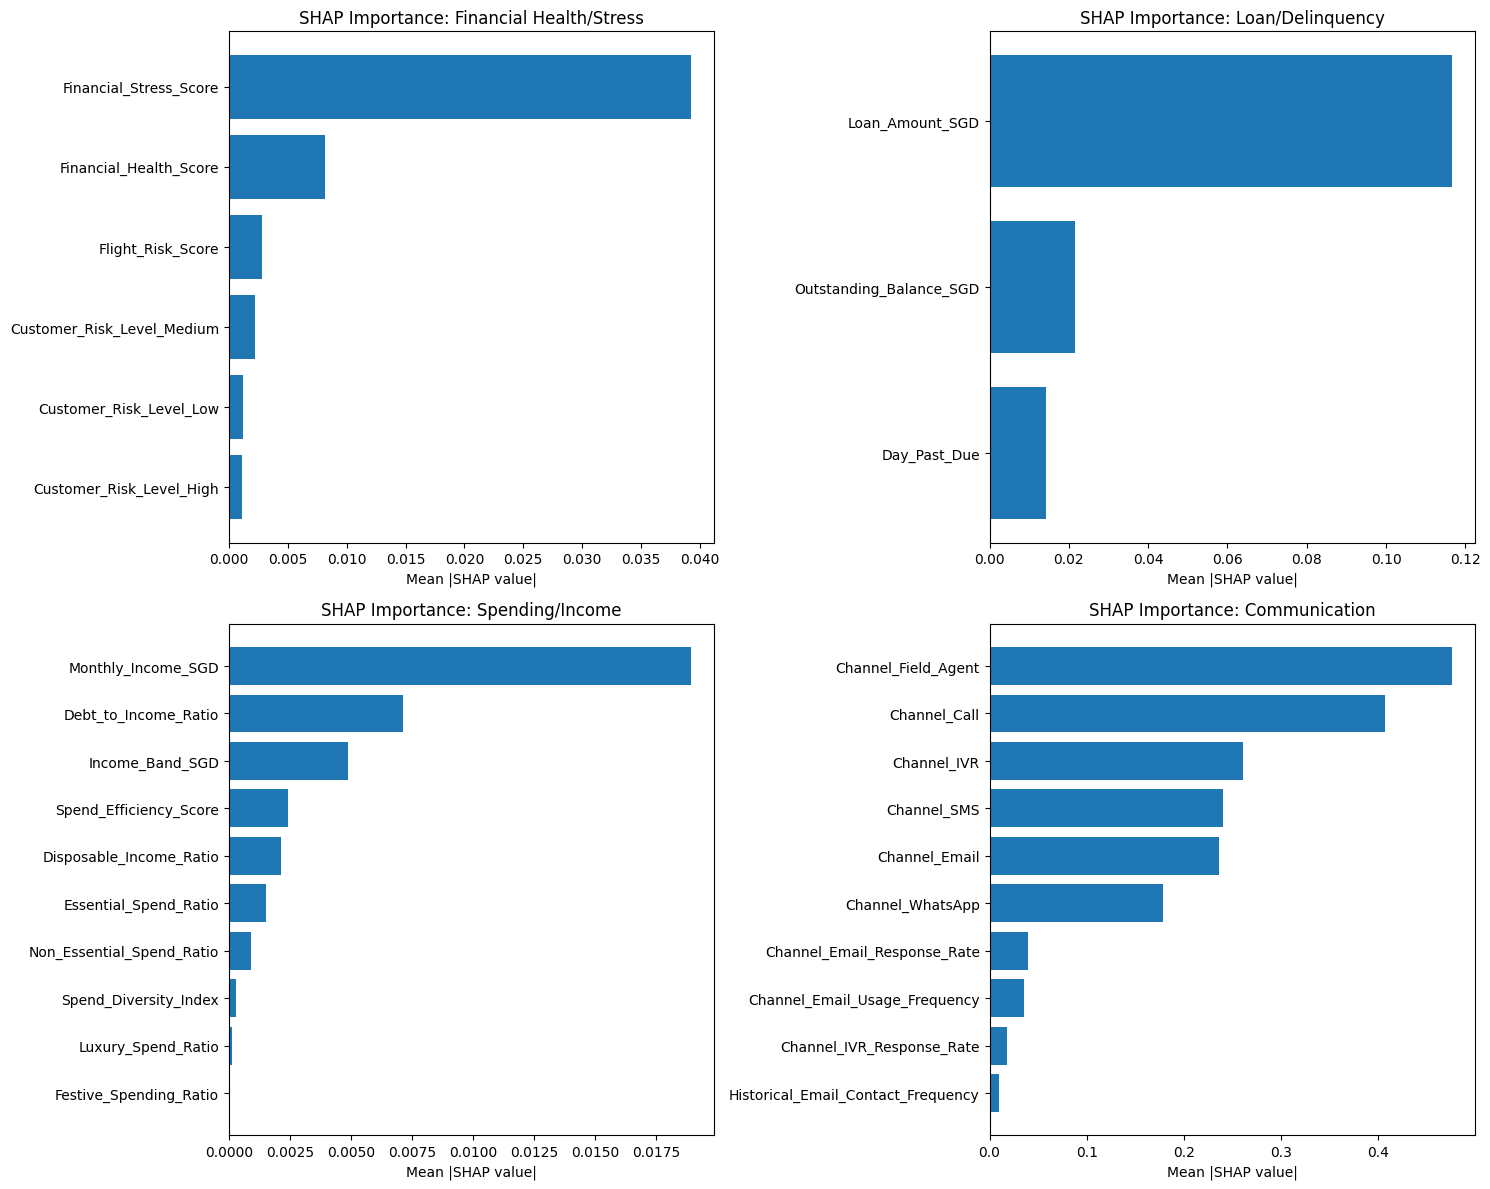

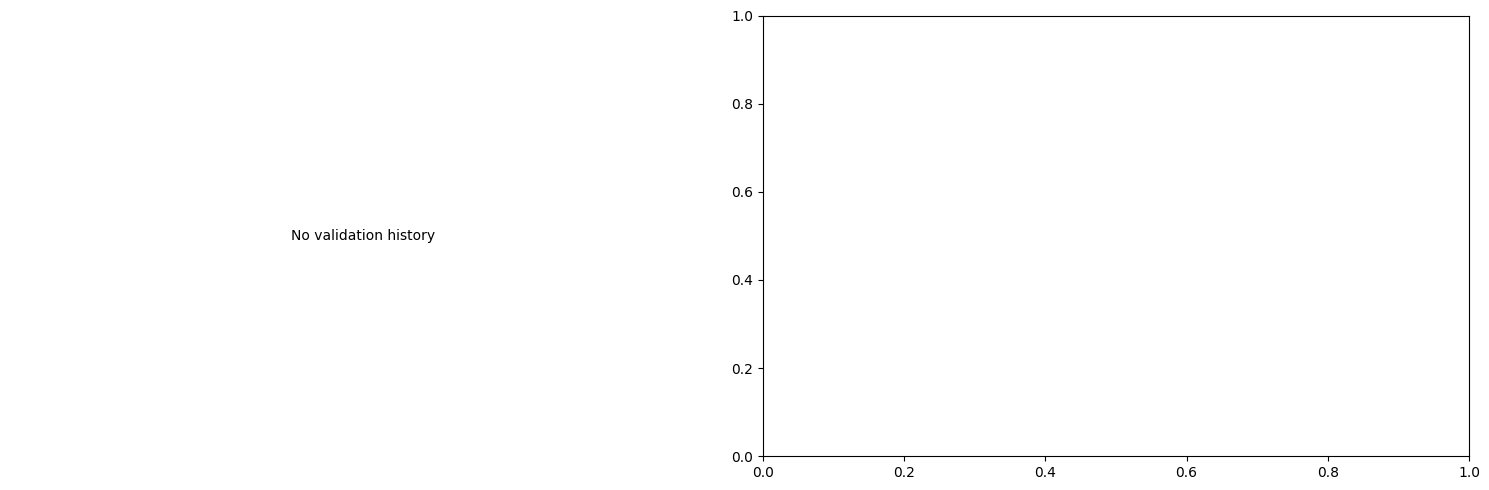

💾 Financial-focused model saved to 'lightgbm_channel_ranker.pkl'

PREDICTION DEMONSTRATION

👤 Customer 1 - SCB995374436
   📊 FINANCIAL PROFILE:
      - Financial_Health_Score   : -2
      - Financial_Stress_Score   : 74.39
      - Day_Past_Due             : 1
      - Loan_Amount_SGD          : 23000.0
      - Monthly_Income_SGD       : 6291.42
      - Debt_to_Income_Ratio     : 0.1168496142365316
   📞 COMMUNICATION PATTERNS:
      - Digital_Savviness_Score  : 0.69111815374614
      - App_Login_Frequency      : 24
   🎯 PREDICTED CHANNEL PREFERENCES:
       1. ★ Call         Score: 2.9683
       2. ★★ WhatsApp     Score: -0.5775
       3. ★★★ SMS          Score: -1.1733
       4. ☆ Email        Score: -2.1750
       5. ☆ IVR          Score: -2.4243
       6. ☆ Field_Agent  Score: -3.0980
   📋 ACTUAL PREFERENCE: Call, WhatsApp, SMS, Email, IVR, Field_Agent

👤 Customer 2 - SCB912200571
   📊 FINANCIAL PROFILE:
      - Financial_Health_Score   : -6
      - Financial_Stress_Score   : 66.95
  

In [16]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import LabelEncoder
import joblib
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

class FinancialChannelRankerWithSHAP:
    """Train LightGBM LambdaRank model specifically focused on financial health, stress,
       ARR scores, spending analysis, loan/delinquency data, and communication patterns"""

    def __init__(self):
        self.model = None
        self.channels = ['SMS', 'Email', 'Call', 'WhatsApp', 'IVR', 'Field_Agent']
        self.label_encoders = {}
        self.feature_cols = None
        self.explainer = None

        # Define feature categories for better analysis
        self.feature_categories = {
            'financial_health': [
                'Financial_Health_Score', 'Financial_Stress_Score', 'ARR_Score',
                'Debt_to_Income_Ratio', 'Credit_Utilization_Ratio', 'Financial_Risk_Segment'
            ],
            'loan_delinquency': [
                'Day_Past_Due', 'Missed_Payments_Count', 'Loan_Amount_SGD',
                'Outstanding_Balance_SGD', 'Payment_Default_Risk', 'Delinquency_Score'
            ],
            'spending_analysis': [
                'Total_Monthly_Spend_SGD', 'Spend_Behavior_Segment',
                'Monthly_Income_SGD', 'Discretionary_Spend_Ratio',
                'Essential_Spend_Ratio', 'Spend_Stability_Score'
            ],
            'communication_patterns': [
                'Contact_Success_Rate', 'Response_Rate_30d', 'Communication_Frequency',
                'Preferred_Contact_Time', 'Channel_Response_Rate_Avg',
                'Digital_Engagement_Score', 'App_Login_Frequency', 'UPI_Transaction_Count'
            ],
            'customer_profile': [
                'Age', 'Customer_Segment', 'Digital_Savviness_Score',
                'Customer_Risk_Level', 'Tenure_Months', 'Education_Focus_Score'
            ]
        }

    def load_and_prepare_data(self, data_path):
        """Load CSV and convert to ranking format with focus on financial and communication features"""
        print("📁 Loading data with focus on financial health and communication patterns...")
        df = pd.read_csv(data_path)
        print(f"✅ Loaded {len(df):,} customers with {len(df.columns):,} features")

        # Exclude label/ID columns only
        exclude_cols = ['Customer_id', 'Channel_Preference_Order', 'Top_Channel']
        self.feature_cols = [col for col in df.columns if col not in exclude_cols]

        # Analyze feature coverage by category
        self._analyze_feature_coverage(df)

        print(f"🔧 Using {len(self.feature_cols)} features for training")
        print("📋 Feature types:")
        print(df[self.feature_cols].dtypes.value_counts())

        # Copy feature DataFrame for encoding
        X = df[self.feature_cols].copy()

        # Encode any remaining object columns
        categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
        if categorical_cols:
            print(f"🔤 Encoding {len(categorical_cols)} categorical columns...")
            for col in categorical_cols:
                le = LabelEncoder()
                X[col] = le.fit_transform(X[col].astype(str))
                self.label_encoders[col] = le

        # Create ranking dataset
        print("🔄 Converting to ranking format...")
        ranking_data = []
        group_sizes = []

        for idx, (_, row) in enumerate(df.iterrows()):
            if (idx + 1) % 1000 == 0:
                print(f"   Processed {idx + 1:,} customers...")

            preference_order = str(row['Channel_Preference_Order']).split(',')
            customer_features = X.iloc[idx].values

            valid_channel_count = 0
            for rank, channel in enumerate(preference_order):
                channel = channel.strip()
                if channel in self.channels:
                    # Channel one-hot encoding
                    channel_features = np.zeros(len(self.channels))
                    channel_idx = self.channels.index(channel)
                    channel_features[channel_idx] = 1

                    combined_features = np.concatenate([customer_features, channel_features])

                    # Enhanced relevance scoring
                    relevance = len(preference_order) - rank
                    if rank == 0:
                        relevance += 2
                    elif rank == 1:
                        relevance += 1

                    ranking_data.append({
                        'features': combined_features,
                        'relevance': relevance
                    })
                    valid_channel_count += 1

            group_sizes.append(valid_channel_count)

        # Create final matrices
        X_ranking = np.array([item['features'] for item in ranking_data])
        y_ranking = np.array([item['relevance'] for item in ranking_data])
        groups = np.array(group_sizes, dtype=int)

        print("📊 Ranking dataset created:")
        print(f"   Total samples: {len(X_ranking):,}")
        print(f"   Total customer groups: {len(groups):,}")
        print(f"   Features per sample: {X_ranking.shape[1]}")
        print(f"   Average channels per customer: {groups.mean():.1f}")

        return X_ranking, y_ranking, groups, df

    def _analyze_feature_coverage(self, df):
        """Analyze which financial, loan, spending, and communication features are available"""

        for category, expected_features in self.feature_categories.items():
            available_features = [f for f in expected_features if f in df.columns]
            coverage_pct = len(available_features) / len(expected_features) * 100

    def train_model(self, X, y, groups, test_size=0.2):
        """Train LightGBM ranker with financial feature focus"""
        print("\n🚀 Training LightGBM Ranker...")

        # Split by groups (customers)
        n_groups = len(groups)
        n_train_groups = int(n_groups * (1 - test_size))
        train_samples = int(groups[:n_train_groups].sum())

        X_train, X_test = X[:train_samples], X[train_samples:]
        y_train, y_test = y[:train_samples], y[train_samples:]
        groups_train, groups_test = groups[:n_train_groups], groups[n_train_groups:]

        print(f"📈 Train set: {len(X_train):,} samples from {len(groups_train):,} customers")
        print(f"📊 Test set:  {len(X_test):,} samples from {len(groups_test):,} customers")

        train_data = lgb.Dataset(X_train, label=y_train, group=groups_train)
        test_data = lgb.Dataset(X_test, label=y_test, group=groups_test, reference=train_data)

        # Enhanced parameters for financial pattern recognition
        params = {
            'objective': 'lambdarank',
            'metric': 'ndcg',
            'ndcg_eval_at': [32],
            'learning_rate': 0.05,
            'num_leaves': 127,  # More leaves for complex financial patterns
            'max_depth': 10,
            'min_data_in_leaf': 15,
            'feature_fraction': 0.7,
            'bagging_fraction': 0.7,
            'bagging_freq': 5,
            'lambda_l1': 0.2,
            'lambda_l2': 0.2,
            'min_gain_to_split': 0.01,
            'verbosity': -1,
            'seed': 42
        }

        print("🔄 Training financial pattern model...")
        self.model = lgb.train(
            params,
            train_data,
            num_boost_round=300,  # More rounds for complex patterns
            valid_sets=[test_data],
            valid_names=['test'],
            callbacks=[lgb.early_stopping(25), lgb.log_evaluation(50)]
        )

        return X_test, y_test, groups_test, X_train, y_train

    def evaluate_model(self, X_test, y_test, groups_test):
        """Evaluate model using NDCG@32 with financial insights"""
        print("\n📈 Evaluating Financial Pattern Model...")
        if self.model is None:
            raise ValueError("Model is not trained.")

        y_pred = self.model.predict(X_test)
        ndcg = self.calculate_ndcg(y_test, y_pred, groups_test, k=32)
        print(f"✅ NDCG@32 Score: {ndcg:.4f}")

        # Additional financial-focused evaluation
        self._analyze_financial_patterns(X_test, y_pred, groups_test)

        return ndcg, y_pred

    def _analyze_financial_patterns(self, X_test, y_pred, groups_test):
        """Analyze how financial features influence predictions"""


        # Get feature importance
        importance = self.model.feature_importance(importance_type='gain')
        feature_names = self.feature_cols + [f'Channel_{ch}' for ch in self.channels]

        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importance
        }).sort_values('importance', ascending=False)

        # Analyze top financial features
        financial_keywords = ['financial', 'risk', 'score', 'ratio', 'balance', 'payment', 'loan', 'debt', 'spend', 'income']
        financial_features = importance_df[importance_df['feature'].str.lower().str.contains('|'.join(financial_keywords))]

    def calculate_ndcg(self, y_true, y_pred, groups, k=32):
        """Compute ndcg_score group-wise."""
        y_true_reshaped = []
        y_pred_reshaped = []

        start_idx = 0
        for group_size in groups:
            end_idx = start_idx + group_size
            if end_idx > len(y_true):
                break
            y_true_reshaped.append(y_true[start_idx:end_idx])
            y_pred_reshaped.append(y_pred[start_idx:end_idx])
            start_idx = end_idx

        return ndcg_score(y_true_reshaped, y_pred_reshaped, k=k)

    def perform_shap_analysis(self, X, sample_size=1000, waterfall_instances=3):
        """Perform SHAP analysis with focus on financial and communication features"""
        print("\n🔍 Performing SHAP Analysis...")

        if X.shape[0] > sample_size:
            X_sample = X[:sample_size]
            print(f"📊 Using first {sample_size} samples for SHAP calculations")
        else:
            X_sample = X
            print(f"📊 Using {len(X_sample)} samples for SHAP calculations")

        # Build feature names
        feature_names = self.feature_cols + [f'Channel_{ch}' for ch in self.channels]

        if X_sample.shape[1] != len(feature_names):
            raise ValueError(f"Feature dimension mismatch: X has {X_sample.shape[1]} cols but feature_names has {len(feature_names)} entries")

        print("🔄 Creating SHAP TreeExplainer...")
        self.explainer = shap.TreeExplainer(self.model, feature_perturbation="tree_path_dependent")

        print("🔄 Calculating SHAP values...")
        shap_values = self.explainer.shap_values(X_sample)
        shap_values = np.array(shap_values)

        if shap_values.ndim == 3:
            shap_values = np.squeeze(shap_values, axis=0)
        if shap_values.ndim != 2:
            raise ValueError(f"Unexpected SHAP values shape: {shap_values.shape}")


        mean_abs_shap = np.abs(shap_values).mean(axis=0)

        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': mean_abs_shap
        }).sort_values('importance', ascending=True)

        # ---------------------------
        # FINANCIAL FEATURES FOCUSED PLOT
        # ---------------------------
        print("📊 Creating Financial Features SHAP plot...")
        self._create_financial_shap_plot(importance_df, feature_names)

        return shap_values, feature_names

    def _create_financial_shap_plot(self, importance_df, feature_names):
        """Create focused SHAP plot for financial, loan, spending, and communication features"""
        # Identify key feature categories
        financial_keywords = ['stress', 'health_score', 'arr', 'risk']
        loan_keywords = ['loan', 'due', 'payment_count', 'delinquency', 'balance']
        spending_keywords = ['spend', 'income', 'budget']
        communication_keywords = ['contact', 'response', 'channel', 'communication', 'engagement']

        categories = {
            'Financial Health/Stress': financial_keywords,
            'Loan/Delinquency': loan_keywords,
            'Spending/Income': spending_keywords,
            'Communication': communication_keywords
        }

        # Plot each category
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()

        for idx, (category, keywords) in enumerate(categories.items()):
            if idx >= len(axes):
                break

            # Filter features for this category
            cat_features = []
            for feature in feature_names:
                if any(keyword in feature.lower() for keyword in keywords):
                    cat_features.append(feature)

            if cat_features:
                cat_importance = importance_df[importance_df['feature'].isin(cat_features)].tail(10)
                axes[idx].barh(cat_importance['feature'], cat_importance['importance'])
                axes[idx].set_title(f'SHAP Importance: {category}')
                axes[idx].set_xlabel('Mean |SHAP value|')

        plt.tight_layout()
        plt.savefig('shap_financial_categories.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

    def plot_training_metrics(self):
        """Plot training metrics with financial insights"""
        if self.model is None:
            print("📊 Model not trained; cannot plot training metrics.")
            return

        try:
            evals_result = self.model.evals_result()
        except Exception:
            evals_result = {}

        plt.figure(figsize=(15, 5))

        # Training history
        plt.subplot(1, 2, 1)
        if 'test' in evals_result:
            ndcg_keys = [k for k in evals_result['test'].keys() if 'ndcg' in k.lower()]
            if ndcg_keys:
                key = ndcg_keys[0]
                plt.plot(evals_result['test'][key], label=f'Validation {key}', linewidth=2)
                plt.title('Financial Model - Validation NDCG', fontsize=14, fontweight='bold')
                plt.xlabel('Iteration')
                plt.ylabel('NDCG')
                plt.legend()
                plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'No validation history', ha='center', va='center')
            plt.axis('off')

        # Feature importance by category
        plt.subplot(1, 2, 2)
        try:
            importance = self.model.feature_importance(importance_type='gain')
            feature_names = self.feature_cols + [f'Channel_{ch}' for ch in self.channels]

            # Categorize features
            categories_importance = {}
            for category, keywords in self.feature_categories.items():
                cat_features = [f for f in feature_names if any(kw in f.lower() for kw in [cat.replace('_', ' ') for cat in category.split('_')])]
                if cat_features:
                    cat_idx = [feature_names.index(f) for f in cat_features if f in feature_names]
                    categories_importance[category] = sum(importance[i] for i in cat_idx if i < len(importance))


        except Exception as e:
            plt.text(0.5, 0.5, f'Category analysis unavailable\n{e}', ha='center', va='center')
            plt.axis('off')

        plt.tight_layout()
        plt.savefig('financial_model_training_metrics.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

    def save_model(self, model_path='lightgbm_channel_ranker.pkl'):
        """Save model artifacts"""
        model_artifacts = {
            'model': self.model,
            'label_encoders': self.label_encoders,
            'channels': self.channels,
            'feature_cols': self.feature_cols,
            'explainer': self.explainer,
            'feature_categories': self.feature_categories
        }
        joblib.dump(model_artifacts, model_path)
        print(f"💾 Financial-focused model saved to '{model_path}'")

    def demonstrate_financial_predictions(self, df, n_customers=5):
        """Show predictions with financial context"""
        print("\n" + "="*70)
        print("PREDICTION DEMONSTRATION")
        print("="*70)

        for i in range(min(n_customers, len(df))):
            customer_data = df.iloc[i:i+1]
            predictions = self._predict_single_customer(customer_data)
            if not predictions:
                continue

            customer_id = customer_data['Customer_id'].iloc[0] if 'Customer_id' in customer_data.columns else f'idx_{i}'
            print(f"\n👤 Customer {i+1} - {customer_id}")

            # Show key financial metrics
            print("   📊 FINANCIAL PROFILE:")
            financial_metrics = [
                'Financial_Health_Score', 'Financial_Stress_Score', 'ARR_Score',
                'Day_Past_Due', 'Loan_Amount_SGD', 'Monthly_Income_SGD',
                'Total_Monthly_Spend_SGD', 'Debt_to_Income_Ratio'
            ]

            for metric in financial_metrics:
                if metric in customer_data.columns:
                    value = customer_data[metric].iloc[0]
                    print(f"      - {metric:25}: {value}")

            # Show communication patterns
            print("   📞 COMMUNICATION PATTERNS:")
            comm_metrics = [
                'Contact_Success_Rate', 'Digital_Savviness_Score',
                'App_Login_Frequency', 'Response_Rate_30d'
            ]

            for metric in comm_metrics:
                if metric in customer_data.columns:
                    value = customer_data[metric].iloc[0]
                    print(f"      - {metric:25}: {value}")

            print("   🎯 PREDICTED CHANNEL PREFERENCES:")
            for rank, pred in enumerate(predictions, 1):
                stars = "★" * min(rank, 3) if rank <= 3 else "☆"
                print(f"      {rank:2}. {stars} {pred['channel']:12} Score: {pred['score']:.4f}")

            # Show actual preferences
            if 'Channel_Preference_Order' in customer_data.columns:
                actual_order = str(customer_data['Channel_Preference_Order'].iloc[0]).split(',')
                print(f"   📋 ACTUAL PREFERENCE: {', '.join(actual_order)}")

    def _predict_single_customer(self, customer_data):
        """Predict channel preferences for a single customer"""
        if self.model is None:
            print("❌ Model not trained yet!")
            return None
        if len(customer_data) != 1:
            print("❌ Expected a single-row DataFrame for prediction.")
            return None

        # Prepare features
        X_customer_df = customer_data[self.feature_cols].copy()

        # Encode categorical columns
        categorical_cols = X_customer_df.select_dtypes(include=['object']).columns.tolist()
        for col in categorical_cols:
            if col in self.label_encoders:
                le = self.label_encoders[col]
                try:
                    X_customer_df[col] = le.transform(X_customer_df[col].astype(str))
                except ValueError:
                    X_customer_df[col] = -1

        customer_features = X_customer_df.iloc[0].values

        # Create samples for each channel
        ranking_samples = []
        for ch in self.channels:
            channel_features = np.zeros(len(self.channels))
            channel_idx = self.channels.index(ch)
            channel_features[channel_idx] = 1
            combined = np.concatenate([customer_features, channel_features])
            ranking_samples.append((ch, combined))

        X_ranking = np.vstack([s[1] for s in ranking_samples])
        preds = self.model.predict(X_ranking)

        channel_preds = []
        for i, (ch, _) in enumerate(ranking_samples):
            channel_preds.append({'channel': ch, 'score': preds[i]})
        channel_preds.sort(key=lambda x: x['score'], reverse=True)
        return channel_preds

def main():
    print("="*70)
    print("CHANNEL RANKER")
    print("="*70)

    trainer = FinancialChannelRankerWithSHAP()

    data_path = 'features_with_labels.csv'
    X, y, groups, df = trainer.load_and_prepare_data(data_path)

    X_test, y_test, groups_test, X_train, y_train = trainer.train_model(X, y, groups)

    ndcg, preds = trainer.evaluate_model(X_test, y_test, groups_test)

    # SHAP analysis
    shap_values, feature_names = trainer.perform_shap_analysis(X_train, sample_size=1000, waterfall_instances=3)

    trainer.plot_training_metrics()
    trainer.save_model()
    trainer.demonstrate_financial_predictions(df, n_customers=5)

    print("\n" + "="*70)
    print("🎉CHANNEL RANKING COMPLETED!")
    print("="*70)
    print(f"📊 Final Results:")
    print(f"   Customers processed: {len(df):,}")
    print(f"   Total features used: {len(trainer.feature_cols)}")
    print(f"   Training samples: {len(X):,}")
    print(f"   NDCG@32: {ndcg:.4f}")
    print("\n📈 SHAP Analysis Output:")
    print("   - shap_financial_categories.png (Category-wise importance)")
    print("\n💾 Model artifact:")
    print("   - lightgbm_channel_ranker.pkl")

if __name__ == "__main__":
    main()


In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

class ChannelRankingDataPreparator:
    """Prepare data for Random Forest Ranker training"""

    def __init__(self):
        self.channels = ['Call', 'SMS', 'WhatsApp', 'Email', 'IVR', 'Field_Agent']
        self.label_encoders = {}
        self.feature_cols = None

    def prepare_ranking_data(self, df):
        """Convert preference data to ranking format"""
        print("Preparing ranking format...")

        # Get feature columns (exclude label columns and Customer_id)
        exclude_cols = ['Customer_id', 'Channel_Preference_Order', 'Preference_Label', 'Top_Channel']
        exclude_cols.extend([col for col in df.columns if 'Prefers_' in col])
        exclude_cols.extend(['Last_Successful_Agent_ID', 'Best_Contact_Agent_IDs'])

        self.feature_cols = [col for col in df.columns if col not in exclude_cols]

        # Encode categorical columns
        X = df[self.feature_cols].copy()
        categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

        if categorical_cols:
            print(f"Encoding {len(categorical_cols)} categorical columns...")
            for col in categorical_cols:
                le = LabelEncoder()
                X[col] = le.fit_transform(X[col].astype(str))
                self.label_encoders[col] = le

        # Create ranking dataset
        ranking_data = []
        group_sizes = []

        print(f"Processing {len(df)} customers...")

        for idx, (_, row) in enumerate(df.iterrows()):
            if (idx + 1) % 10000 == 0:
                print(f"Processed {idx + 1:,} customers")

            customer_id = row['Customer_id']
            preference_order = row['Channel_Preference_Order'].split(',')

            # Get customer features
            customer_features = X.iloc[idx].values

            # Create one sample per channel
            for rank, channel in enumerate(preference_order):
                if channel in self.channels:
                    # Channel one-hot encoding
                    channel_features = np.zeros(len(self.channels))
                    channel_idx = self.channels.index(channel)
                    channel_features[channel_idx] = 1

                    # Combine customer and channel features
                    combined_features = np.concatenate([customer_features, channel_features])

                    # Relevance score as integer
                    relevance = len(self.channels) - rank

                    ranking_data.append({
                        'customer_id': customer_id,
                        'channel': channel,
                        'features': combined_features,
                        'relevance': relevance,
                        'group_id': idx
                    })

            group_sizes.append(len(self.channels))

        # Convert to arrays
        X_ranking = np.array([item['features'] for item in ranking_data])
        y_ranking = np.array([item['relevance'] for item in ranking_data])
        groups = np.array(group_sizes)

        print(f"\nRanking dataset created:")
        print(f"Total samples: {len(X_ranking):,}")
        print(f"Total customers (groups): {len(groups):,}")
        print(f"Features per sample: {X_ranking.shape[1]}")
        print(f"Group sizes (samples per customer): {groups[0]} (all should be {len(self.channels)})")
        print(f"Relevance score range: {y_ranking.min()} to {y_ranking.max()}")

        return X_ranking, y_ranking, groups

def train_random_forest_ranker(X, y, groups, test_size=0.2, random_state=42):
    """Train Random Forest model for ranking"""
    print("\n" + "="*60)
    print("TRAINING RANDOM FOREST RANKER MODEL")
    print("="*60)

    # Calculate split points for groups
    n_train_groups = int(len(groups) * (1 - test_size))
    train_samples = sum(groups[:n_train_groups])

    # Split data
    X_train = X[:train_samples]
    y_train = y[:train_samples]
    groups_train = groups[:n_train_groups]

    X_test = X[train_samples:]
    y_test = y[train_samples:]
    groups_test = groups[n_train_groups:]

    print(f"Feature matrix shape: {X_train.shape}")
    print(f"Label vector shape: {y_train.shape}")
    print(f"Number of groups: {len(groups_train):,}")
    print(f"\nTrain set: {len(X_train):,} samples from {len(groups_train):,} customers")
    print(f"Test set: {len(X_test):,} samples from {len(groups_test):,} customers")

    # Random Forest parameters
    rf_params = {
        'n_estimators': 100,
        'max_depth': 10,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 'sqrt',
        'bootstrap': True,
        'random_state': random_state,
        'n_jobs': -1,
        'verbose': 0  # Suppress training output
    }

    # Initialize and train Random Forest
    print("\nTraining Random Forest...")
    model = RandomForestRegressor(**rf_params)
    model.fit(X_train, y_train)

    print("Model training completed successfully!")

    # Make predictions
    print("\nMaking predictions...")
    y_pred = model.predict(X_test)

    # Calculate NDCG
    print("Calculating NDCG score...")
    # Reshape predictions for NDCG calculation
    y_test_reshaped = []
    y_pred_reshaped = []

    start_idx = 0
    for group_size in groups_test:
        end_idx = start_idx + group_size
        y_test_reshaped.append(y_test[start_idx:end_idx])
        y_pred_reshaped.append(y_pred[start_idx:end_idx])
        start_idx = end_idx

    ndcg = ndcg_score(y_test_reshaped, y_pred_reshaped)
    print(f"NDCG Score: {ndcg:.4f}")

    return model, ndcg

# Main execution
if __name__ == "__main__":
    print("="*60)
    print("PREPARING CHANNEL RANKING DATA FOR RANDOM FOREST RANKER")
    print("="*60)

    # Load data
    print("Loading features_with_channel_labels.csv...")
    try:
        df = pd.read_csv('features_with_channel_labels.csv')
        print(f"Loaded data shape: {df.shape}")
    except FileNotFoundError:
        print("Error: features_with_channel_labels.csv not found!")
        print("Please run the labeling pipeline first.")
        exit(1)

    # Prepare data
    preparator = ChannelRankingDataPreparator()
    X, y, groups = preparator.prepare_ranking_data(df)

    # Train model
    model, ndcg_score = train_random_forest_ranker(X, y, groups)

    # Save model only (no preparator)
    model_filename = 'random_forest_channel_ranker.pkl'
    joblib.dump(model, model_filename)
    print(f"\nModel saved as '{model_filename}'")

    print("\n" + "="*60)
    print("MODEL TRAINING COMPLETED SUCCESSFULLY!")
    print("="*60)
    print(f"Feature columns used: {X.shape[1]}")
    print(f"Model saved as: {model_filename}")
    print(f"Total customers processed: {len(df):,}")
    print(f"Final NDCG Score: {ndcg_score:.4f}")

PREPARING CHANNEL RANKING DATA FOR RANDOM FOREST RANKER
Loading features_with_channel_labels.csv...
Error: features_with_channel_labels.csv not found!
Please run the labeling pipeline first.
Preparing ranking format...
Encoding 1 categorical columns...
Processing 100000 customers...
Processed 10,000 customers
Processed 20,000 customers
Processed 30,000 customers
Processed 40,000 customers
Processed 50,000 customers
Processed 60,000 customers
Processed 70,000 customers
Processed 80,000 customers
Processed 90,000 customers
Processed 100,000 customers

Ranking dataset created:
Total samples: 600,000
Total customers (groups): 100,000
Features per sample: 73
Group sizes (samples per customer): 6 (all should be 6)
Relevance score range: 1 to 6

TRAINING RANDOM FOREST RANKER MODEL
Feature matrix shape: (480000, 73)
Label vector shape: (480000,)
Number of groups: 80,000

Train set: 480,000 samples from 80,000 customers
Test set: 120,000 samples from 20,000 customers

Training Random Forest...
